### Machine Learning Project (Second deliverable)- **Cars 4 You**

### Group Member Contribution:
Khadija Ennaifer (20250439)- Zeineb Hajji(20250535)- Batoul Abdullah (20250536) - Ozougwu Chukwuebuka (20250449)

### Abstract
This project focuses on building a model that predicts car prices using real data from different brands and models.
The analysis started with exploring and cleaning the dataset to fix missing values, handle outliers, and correct inconsistent entries.
Several numerical and categorical features such as mileage, engine size, year, fuel type, and transmission were used to understand what drives car prices.
After preparing the data, different regression models were tested and compared to find the most accurate one.
The final model gives reliable price estimates and shows how data analysis and machine learning can support decision-making in the car market.

### **INDEX**

- [Abstract](#abstract)


- [I. Identifying Business Needs](#i-identifying-business-needs)

- [II. Exploratory Data Analysis (EDA)](#ii-exploratory-data-analysis-eda)
  - [2.1 Importing Libraries](#21-importing-libraries)
  - [2.2 Importing and Exploring Data](#22-importing-and-exploring-data)
  - [2.3 Missing Values](#23-missing-values)
  - [2.4 Unique Values](#24-unique-values)
  - [2.5 Duplicates](#25-duplicates)
  - [2.6 Statistical Description and Outlier Detection](#26-statistical-description-and-outlier-detection)
    
  - [2.7 Correlation Matrix](#27-correlation-matrix)

- [III. Data Cleaning and Preprocessing](#iii-data-cleaning-and-preprocessing)
  - [3.1 Handling Data Types](#31-handling-data-types)
  - [3.2 Fixing Typos](#32-fixing-typos)
    - [Fuel Type](#fuel-type)
    - [Transmission](#transmission)
    - [Brand](#brand)
  - [3.3 Handling Negative Values](#33-handling-negative-values)
  - [3.4 Train–Validation Split](#34-trainvalidation-split)
  - [3.5 Handling Missing Values](#35-handling-missing-values)
  - [3.6 Handling Outliers (Z-score)](#36-handling-outliers-z-score)

- [IV. Feature Engineering and Selection](#iv-feature-engineering-and-selection)
  - [4.1 Creating New Features](#41-creating-new-features)
  - [4.2 Encoding and Scaling](#42-encoding-and-scaling)
    - [Categorical Variables Encoding](#categorical-variables-encoding)
    - [Numerical Variables Scaling](#numerical-variables-scaling)
  - [4.3 Feature Selection](#43-feature-selection)
    - [4.3.1 Filter Methods](#431-filter-methods)
      - [Constant Variables](#constant-variables)
      - [Correlation Indices](#correlation-indices)
    - [4.3.2 Wrapper Method (RFE)](#432-wrapper-method-rfe)
    - [4.3.3 Embedded Method](#433-embedded-method)
    - [4.3.4 Final Selected Features](#434-final-selected-features)
  - [Key Decisions](#key-decisions)

- [V. Model Training](#v-model-training)
  - [5.1 Ridge Regression](#51-ridge-regression)
  - [5.2 MLP Regressor](#52-mlp-regressor)
  - [5.3 Decision Tree Regressor](#53-decision-tree-regressor)
  - [5.4 K-Nearest Neighbors](#54-k-nearest-neighbors)
  - [5.5 Support Vector Machine (SVM)](#55-support-vector-machine-svm)
    

- [VI. Comparing the Models](#vi-comparing-the-models)

- [VII. Selecting the Best Model](#vii-selecting-the-best-model)
- [VIII. Exporting Predictions into a csv file](#predictions)
- [IX. Conclusion ](#viii-conclusion-and-future-work)


### I. Identifying Business Needs

Buying or selling a used car can be difficult because prices change depending on many factors like brand, model, year, mileage, and fuel type.
Cars 4 You wants to build a machine learning model that can predict the fair price of a used car.

This will help:

-Sellers set a fair and competitive price.

-Buyers know if they are paying too much.

-Dealers manage their stock and pricing better.

The goal is to create a model that predicts the car’s market value (price) based on its features with good accuracy and reliability.

### II. Exploratory Data Analysis (EDA)

In this section, we explore the dataset to gain a clear understanding of its structure, key characteristics, and overall quality. The Exploratory Data Analysis (EDA) helps us examine statistical distributions, uncover relationships between variables, and identify potential issues such as missing values, inconsistencies, or outliers.

By analyzing these aspects early on, we can better understand the data and make informed decisions during the preprocessing and modeling stages. This step is essential for building reliable and meaningful predictive models based on well-understood data.


####  1. Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, RFE, SelectFromModel
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso, LassoCV
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV


#### 2. Importing and exploring Data

In [3]:
train = pd.read_csv("train.csv")
train.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [4]:
train.dtypes

,0
carID,int64
Brand,object
model,object
year,float64
price,int64
transmission,object
mileage,float64
fuelType,object
tax,float64
mpg,float64


In [5]:
#Upload Test dataset
test = pd.read_csv("test.csv")
test.head()

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
1,106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
2,80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
3,100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
4,81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0


In [6]:
test.dtypes

,0
carID,int64
Brand,object
model,object
year,float64
transmission,object
mileage,float64
fuelType,object
tax,float64
mpg,float64
engineSize,float64


##### 2.1 Missing values

In [7]:
# =========================
# 1. Number of Missing Values in the training dataset
# =========================
print("\n================ MISSING VALUES ================\n")
print(train.isnull().sum())


================ MISSING VALUES ================

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64


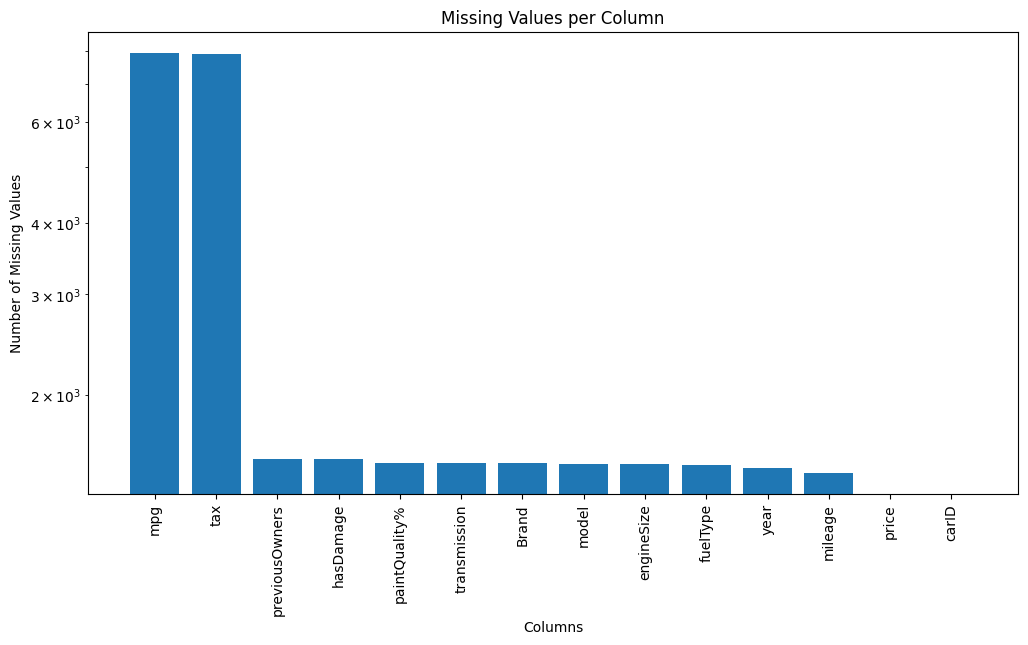

In [8]:
#Check Missing Values
missing_data=train.isnull().sum()
missing_data = missing_data.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(missing_data.index, missing_data.values)  # x = columns, y = counts
plt.yscale("log")
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column")
plt.show()

In [9]:
# =========================
# 1. Number of Missing Values in the testing dataset
# =========================
print("\n================ MISSING VALUES ================\n")
print(test.isnull().sum())


================ MISSING VALUES ================

carID                0
Brand              649
model              650
year               653
transmission       623
mileage            689
fuelType           656
tax               3308
mpg               3288
engineSize         628
paintQuality%      625
previousOwners     597
hasDamage          597
dtype: int64


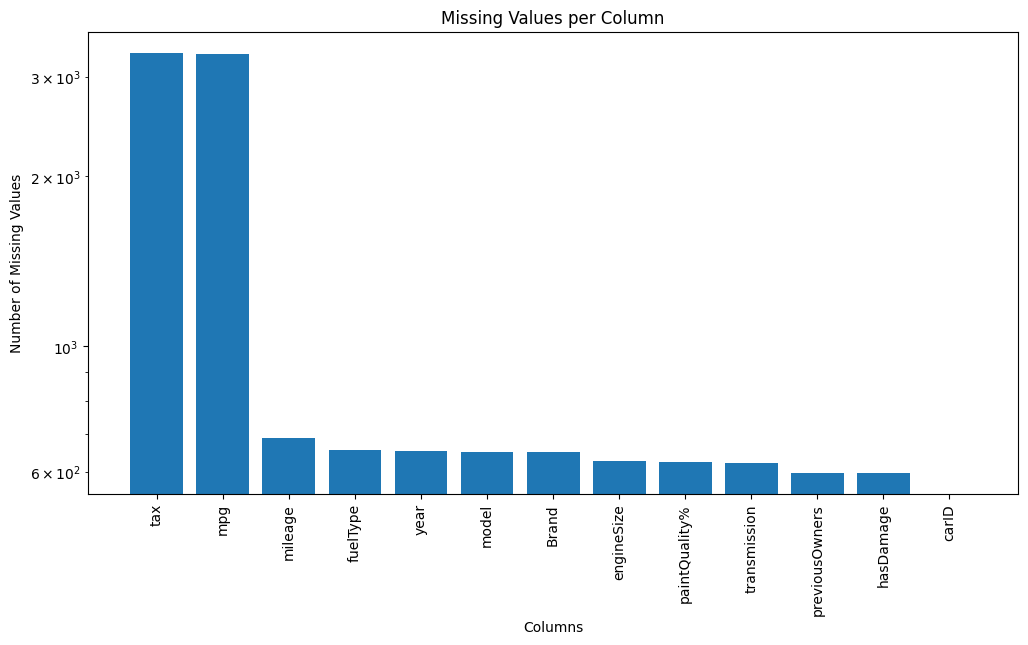

In [10]:
missing_data_test=test.isnull().sum()
missing_data_test = missing_data_test.sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(missing_data_test.index, missing_data_test.values)  # x = columns, y = counts
plt.yscale("log")
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column")
plt.show()
#Checking missing values for the testing dataset

From these observations (train and test), we can conclude that mpg and tax are the two columns with the most missing values
 We noticed that the missing values are not completely random because as:
* 'mpg'  might indicate that the car is new and hasn’t been driven yet.
* 'tax' could mean that, at the time of purchase, the tax value was recorded as 0 or not yet applied.

Missing values were handled to balance data quality and information retention.

##### 2.2 Unique values

In [11]:
# =========================
# 2. Unique Values in Categorical Features
# =========================
print("\n================ CATEGORICAL UNIQUE VALUES ================\n")

print("Fuel Type:")
print(train['fuelType'].unique())   # Check for typos / inconsistencies
print("\nTransmission:")
print(train['transmission'].unique())  # e.g. 'anual' typo
print("\nBrand:")
print(train['Brand'].unique())
print("\nModel:")
print(train['model'].unique())




================ CATEGORICAL UNIQUE VALUES ================

Fuel Type:
['Petrol' 'Diesel' 'etrol' 'Hybrid' 'diesel' 'iesel' nan 'petrol' 'PETROL'
 'Diese' 'Petro' 'DIESEL' 'petro' 'HYBRID' 'ybri' 'Other' 'DIESE' 'Hybri'
 'ETROL' 'ybrid' 'PETRO' 'hybrid' 'IESEL' 'Electric' 'ther' 'iese' 'etro'
 'ETRO' 'diese' 'Othe' 'YBRID' 'HYBRI' 'OTHER' 'other' 'IESE']

Transmission:
['Semi-Auto' 'Manual' 'anual' 'Semi-Aut' 'Automatic' 'manual' nan
 'unknown' 'Manua' 'AUTOMATIC' 'MANUAL' 'semi-auto' ' Manual ' 'automatic'
 'emi-Auto' 'SEMI-AUTO' 'SEMI-AUT' 'Automati' 'ANUAL' 'utomatic' 'unknow'
 'EMI-AUTO' 'manua' 'anua' 'emi-Aut' 'MANUA' 'emi-auto' 'UTOMATIC'
 ' manual ' ' MANUAL ' 'UNKNOWN' 'nknown' 'automati' 'Other' 'semi-aut'
 ' Manual' 'AUTOMATI' 'utomati' 'Manual ' 'manual ' 'nknow']

Brand:
['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'M

From the above unique values, we can observe several typographical errors in the data, which will be corrected in a later preprocessing step

#### 2.3  Duplicates

In [12]:
duplicates = train.duplicated()
print("Duplicate rows (True = duplicate):\n", duplicates)

# Count duplicates
num_duplicates = train.duplicated().sum()
print("\nNumber of duplicate rows:", num_duplicates)



Duplicate rows (True = duplicate):
 0        False
1        False
2        False
3        False
4        False
         ...  
75968    False
75969    False
75970    False
75971    False
75972    False
Length: 75973, dtype: bool

Number of duplicate rows: 0


We obsereved that there are no duplicates in our dataset

#### 2.4  Statistical description and outlier detection

In [13]:

# =========================
# 3. Numerical Statistics
# =========================
print("\n================ NUMERICAL DESCRIPTION ================\n")
print(train.describe())   # Check for negatives, outliers, ranges



================ NUMERICAL DESCRIPTION ================

              carID          year          price        mileage           tax  \
count  75973.000000  74482.000000   75973.000000   74510.000000  68069.000000   
mean   37986.000000   2017.096611   16881.889553   23004.184088    120.329078   
std    21931.660338      2.208704    9736.926322   22129.788366     65.521176   
min        0.000000   1970.000000     450.000000  -58540.574478    -91.121630   
25%    18993.000000   2016.000000   10200.000000    7423.250000    125.000000   
50%    37986.000000   2017.000000   14699.000000   17300.000000    145.000000   
75%    56979.000000   2019.000000   20950.000000   32427.500000    145.000000   
max    75972.000000   2024.121759  159999.000000  323000.000000    580.000000   

                mpg    engineSize  paintQuality%  previousOwners  hasDamage  
count  68047.000000  74457.000000   74449.000000    74423.000000    74425.0  
mean      55.152666      1.660136      64.590667        

- Most vehicles are from model years 2016–2019, but some unrealistic values indicate inconsistencies

- Price and mileage show high variability, reflecting a wide range of vehicle conditions and market segments

- Negative values appear in mileage, tax, mpg, and engine size, indicating potential data errors

- Paint quality percentages exceed logical bounds, suggesting recording or scaling issues

- Previous owners include negative or non-integer values, highlighting inconsistencies

- Some variables, like hasDamage, show little or no variability, reducing their modeling usefulness

   
From these observations , we can confirm the necessity of the data cleaning needed in the next steps

##### Checking outliers with IQR

Since the outliers check can only be done for numerical vlaues, We will have to create a new list of the numerical variables

In [14]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

outliers_summary = {}

for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

# Display number of outliers per numeric column
outliers_summary

{'carID': 0,
 'year': 1791,
 'price': 2695,
 'mileage': 3617,
 'tax': 20306,
 'mpg': 1200,
 'engineSize': 716,
 'paintQuality%': 0,
 'previousOwners': 734,
 'hasDamage': 0}

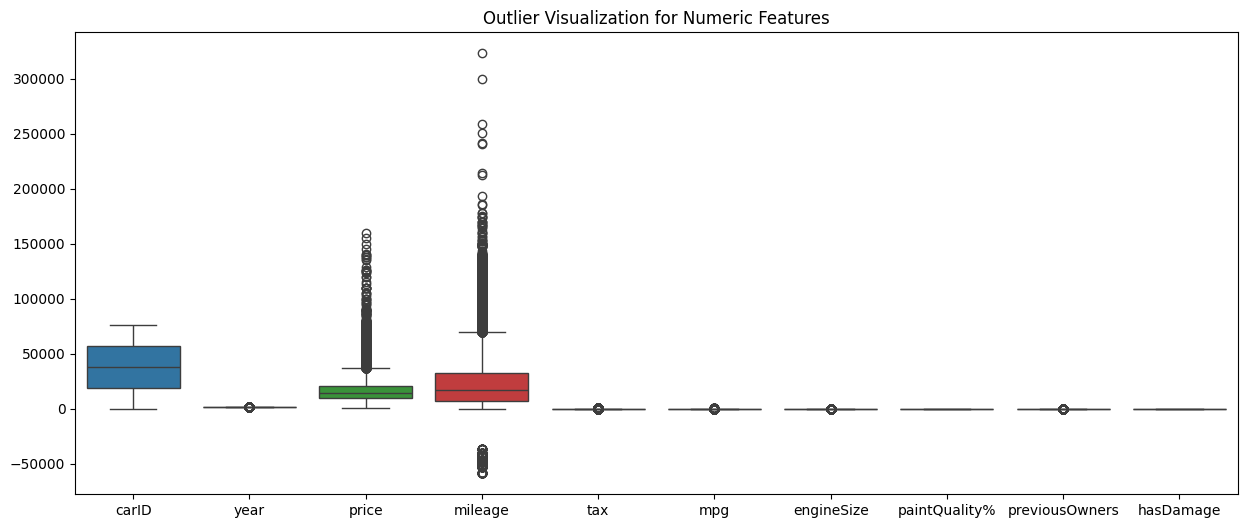

In [15]:

plt.figure(figsize=(15, 6))
sns.boxplot(data=train[numeric_cols])
plt.title("Outlier Visualization for Numeric Features")
plt.show()

Instead of blindly removing all outliers, decisions were made based on their potential impact on model learning and the realism of the observed values in the context of car pricing.

To help reach our goal, we created plots, which enabled us to notice that some variables like price and mileage clearly have outliers .It indeed helped us identify unusual categories that might need special handling that we will do later on.

##### 2.5 Correlation matrix

The correlation matrix enables us to discover the relationships between the numerical features in the dataset

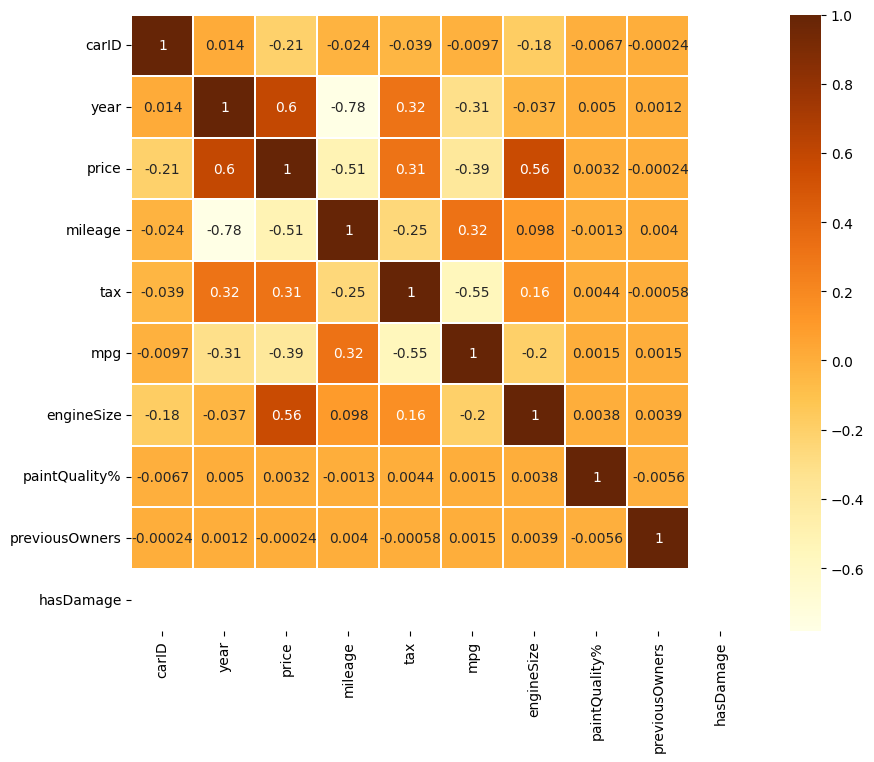

In [16]:
# Select numerical columns for correlation analysis
#train= train.drop(columns=['carID'])
corr_data = train.select_dtypes(include=['number'])

# Compute the Spearman correlation matrix (Pearson is the default)
correlation_matrix = corr_data.corr(method='spearman')

# Plot the correlation heatmap
plt.figure(figsize=(10,8 ))
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrBr', linewidths=0.1)
plt.show()

From this correlation map, We can already observe some correlations (ex:year and price , price and enginesize)
However, we will wait and not give conclusions now since we haven't cleaned the data yet and it has some inconsistencies

### 3. Data Cleaning and preprocessing

We will clean the dataset by handling missing values, fixing errors, and resolving inconsistencies we discovered in the previous cells. Preprocessing will include feature engineering, encoding categorical variables, normalizing numeric data to ensure that we have reliable data .

#### 3.1 Handle data types and distinguish categorical variables from numerical ones

In [17]:
train["hasDamage"].astype('bool')

,hasDamage
0,False
1,False
2,False
3,False
4,False
...,...
75968,False
75969,False
75970,False
75971,False


In [18]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols= ['Brand', 'model', 'transmission', 'fuelType','hasDamage']
print(f"Numeric: {len(num_cols)} → {num_cols[:5]}")
print(f"Categorical: {len(cat_cols)} → {cat_cols[:5]}")

Numeric: 7 → ['year', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical: 5 → ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage']


#### 3.2 Fix typos

In the EDA, we noticed that the columns Fuel Type, Transmission ,model and Brand have a lot of typos.
We will fix them to have relevant informations

#### Cleaning the typos in the Fuel Type column

In [19]:
# Map all variations to standard values
fuel_mapping = {
    # Petrol
    'Petrol': 'Petrol', 'petrol': 'Petrol', 'PETROL': 'Petrol',
    'etrol': 'Petrol', 'Petro': 'Petrol', 'PETRO': 'Petrol', 'etro': 'Petrol', 'ETRO': 'Petrol',

    # Diesel
    'Diesel': 'Diesel', 'diesel': 'Diesel', 'DIESEL': 'Diesel',
    'iesel': 'Diesel', 'IESEL': 'Diesel', 'iese': 'Diesel', 'IESE': 'Diesel',
    'Diese': 'Diesel', 'DIESE': 'Diesel', 'diese': 'Diesel',

    # Hybrid
    'Hybrid': 'Hybrid', 'hybrid': 'Hybrid', 'HYBRID': 'Hybrid',
    'ybri': 'Hybrid', 'Hybri': 'Hybrid', 'ybrid': 'Hybrid', 'YBRID': 'Hybrid', 'HYBRI': 'Hybrid',

    # Other / Electric
    'Other': 'Other', 'other': 'Other', 'OTHER': 'Other',
    'Othe': 'Other', 'ther': 'Other',
    'Electric': 'Electric'
}

train['fuelType'] = train['fuelType'].map(fuel_mapping).fillna('Unknown')

print("fuelType cleaned:")
print(train['fuelType'].value_counts())

fuelType cleaned:
fuelType
Petrol      41147
Diesel      30885
Hybrid       2225
Unknown      1545
Other         167
Electric        4
Name: count, dtype: int64


In [20]:
test['fuelType'] = test['fuelType'].map(fuel_mapping).fillna('Unknown')

#### Cleaning the typos in the Transmission column

In [21]:
trans_mapping = {
    # Manual
    'Manual': 'Manual', 'manual': 'Manual', 'MANUAL': 'Manual',
    'anual': 'Manual', 'Manua': 'Manual', 'MANUA': 'Manual', 'manua': 'Manual', 'anua': 'Manual',
    ' Manual ': 'Manual', ' Manual': 'Manual', 'manual ': 'Manual', ' MANUAL ': 'Manual',

    # Automatic
    'Automatic': 'Automatic', 'automatic': 'Automatic', 'AUTOMATIC': 'Automatic',
    'Automati': 'Automatic', 'AUTOMATI': 'Automatic', 'automati': 'Automatic',
    'utomatic': 'Automatic', 'UTOMATIC': 'Automatic', 'utomati': 'Automatic',

    # Semi-Auto
    'Semi-Auto': 'Semi-Auto', 'semi-auto': 'Semi-Auto', 'SEMI-AUTO': 'Semi-Auto',
    'Semi-Aut': 'Semi-Auto', 'SEMI-AUT': 'Semi-Auto', 'emi-Auto': 'Semi-Auto', 'EMI-AUTO': 'Semi-Auto',
    'emi-Aut': 'Semi-Auto', 'emi-auto': 'Semi-Auto', 'semi-aut': 'Semi-Auto',

    # Other / Unknown
    'unknown': 'Unknown', 'unknow': 'Unknown', 'nknown': 'Unknown', 'UNKNOWN': 'Unknown',
    'Other': 'Other'
}

train['transmission'] =train['transmission'].map(trans_mapping).fillna('Unknown')
test['transmission'] =test['transmission'].map(trans_mapping).fillna('Unknown')
print("\ntransmission cleaned:")
print(train['transmission'].value_counts())


transmission cleaned:
transmission
Manual       41592
Semi-Auto    16872
Automatic    15211
Unknown       2293
Other            5
Name: count, dtype: int64


#### Cleaning the typos in the Brand column

In [22]:
brand_mapping = {
    # VW
    'VW': 'VW', 'vw': 'VW', 'V': 'VW', 'w': 'VW', 'W': 'VW', 'v': 'VW',

    # Toyota
    'Toyota': 'Toyota', 'toyota': 'Toyota', 'TOYOTA': 'Toyota',
    'Toyot': 'Toyota', 'TOYOT': 'Toyota', 'oyota': 'Toyota', 'OYOTA': 'Toyota', 'toyot': 'Toyota',

    # Audi
    'Audi': 'Audi', 'audi': 'Audi', 'AUDI': 'Audi',
    'udi': 'Audi', 'UDI': 'Audi', 'Aud': 'Audi', 'AUD': 'Audi', 'aud': 'Audi',

    # Ford
    'Ford': 'Ford', 'ford': 'Ford', 'FORD': 'Ford',
    'For': 'Ford', 'FOR': 'Ford', 'ord': 'Ford', 'or': 'Ford', 'ORD': 'Ford',

    # BMW
    'BMW': 'BMW', 'bmw': 'BMW', 'BM': 'BMW', 'MW': 'BMW', 'mw': 'BMW',

    # Skoda
    'Skoda': 'Skoda', 'skoda': 'Skoda', 'SKODA': 'Skoda',
    'koda': 'Skoda', 'KODA': 'Skoda', 'Skod': 'Skoda', 'SKOD': 'Skoda', 'kod': 'Skoda',

    # Mercedes
    'Mercedes': 'Mercedes', 'mercedes': 'Mercedes', 'MERCEDES': 'Mercedes',
    'Mercede': 'Mercedes', 'MERCEDE': 'Mercedes', 'ercedes': 'Mercedes', 'ERCEDES': 'Mercedes',
    'mercede': 'Mercedes', 'ercede': 'Mercedes',

    # Opel
    'Opel': 'Opel', 'opel': 'Opel', 'OPEL': 'Opel',
    'Ope': 'Opel', 'OPE': 'Opel', 'pel': 'Opel', 'PEL': 'Opel', 'pe': 'Opel',

    # Hyundai
    'Hyundai': 'Hyundai', 'hyundai': 'Hyundai', 'HYUNDAI': 'Hyundai',
    'yundai': 'Hyundai', 'YUNDAI': 'Hyundai', 'Hyunda': 'Hyundai', 'HYUNDA': 'Hyundai',
    'yunda': 'Hyundai'
}

train['Brand'] = train['Brand'].map(brand_mapping).fillna('Other')
test['Brand'] = test['Brand'].map(brand_mapping).fillna('Other')
print("\nBrand cleaned:")
print(train['Brand'].value_counts())


Brand cleaned:
Brand
Ford        16056
Mercedes    11674
VW          10385
Opel         9348
BMW          7392
Audi         7322
Toyota       4622
Skoda        4302
Hyundai      3333
Other        1539
Name: count, dtype: int64


Cleaning the typos in the the Model Column

In [23]:
model_mapping = {
    # VW
    'golf': 'Golf', 'gol': 'Golf', 'glf': 'Golf', 'gof': 'Golf', 'golf s': 'Golf', 'golf sv': 'Golf',
    'passat': 'Passat', 'passa': 'Passat',
    'polo': 'Polo', 'pol': 'Polo',
    'tiguan': 'Tiguan', 'tigua': 'Tiguan', 'tiguan allspace': 'Tiguan', 'tiguan allspac': 'Tiguan',
    'touareg': 'Touareg', 'touare': 'Touareg',
    'sharan': 'Sharan', 'shara': 'Sharan',
    'touran': 'Touran', 'toura': 'Touran',
    'up': 'Up',
    't-roc': 'T-Roc', 't-ro': 'T-Roc',
    't-cross': 'T-Cross', 't-cros': 'T-Cross',
    'scirocco': 'Scirocco', 'scirocc': 'Scirocco',
    'arteon': 'Arteon', 'arteo': 'Arteon',
    'amarok': 'Amarok', 'amaro': 'Amarok',
    'caddy': 'Caddy', 'caddy maxi': 'Caddy', 'caddy life': 'Caddy', 'caddy maxi life': 'Caddy', 'caddy maxi lif': 'Caddy',
    'caravelle': 'Caravelle', 'caravell': 'Caravelle',
    'california': 'California',
    'jetta': 'Jetta',
    'cc': 'CC',
    'eos': 'EOS',
    'beetle': 'Beetle', 'beetl': 'Beetle',
    'fox': 'Fox',

    # Toyota
    'yaris': 'Yaris', 'yari': 'Yaris',
    'aygo': 'Aygo', 'ayg': 'Aygo',
    'corolla': 'Corolla', 'coroll': 'Corolla',
    'prius': 'Prius',
    'rav4': 'RAV4', 'rav': 'RAV4',
    'c-hr': 'C-HR', 'c-h': 'C-HR',
    'auris': 'Auris', 'auri': 'Auris',
    'avensis': 'Avensis',
    'camry': 'Camry',
    'land cruiser': 'Land Cruiser', 'land cruise': 'Land Cruiser',
    'hilux': 'Hilux', 'hilu': 'Hilux',
    'proace verso': 'Proace Verso',
    'gt86': 'GT86',
    'supra': 'Supra',
    'verso': 'Verso', 'vers': 'Verso',
    'verso-s': 'Verso-S',
    'urban cruiser': 'Urban Cruiser', 'urban cruise': 'Urban Cruiser',
    'iq': 'IQ',

    # Audi
    'a1': 'A1',
    'a3': 'A3',
    'a4': 'A4',
    'a5': 'A5',
    'a6': 'A6',
    'a7': 'A7',
    'a8': 'A8',
    'q2': 'Q2',
    'q3': 'Q3',
    'q5': 'Q5',
    'q7': 'Q7',
    'q8': 'Q8',
    'tt': 'TT',
    'r8': 'R8',
    'rs3': 'RS3',
    'rs4': 'RS4',
    'rs5': 'RS5',
    'rs6': 'RS6',
    'sq5': 'SQ5',
    'sq7': 'SQ7',
    's3': 'S3',
    's4': 'S4',
    's5': 'S5',
    's8': 'S8',
    'a2': 'A2',

    # Ford
    'fiesta': 'Fiesta', 'fiest': 'Fiesta',
    'focus': 'Focus', 'focu': 'Focus',
    'ka': 'Ka', 'ka+': 'Ka',
    'kuga': 'Kuga', 'kug': 'Kuga',
    'mondeo': 'Mondeo', 'monde': 'Mondeo',
    'puma': 'Puma',
    'ecosport': 'EcoSport', 'ecospor': 'EcoSport',
    's-max': 'S-Max', 's-ma': 'S-Max',
    'galaxy': 'Galaxy', 'galax': 'Galaxy',
    'tourneo connect': 'Tourneo Connect', 'grand tourneo connect': 'Tourneo Connect', 'grand tourneo connec': 'Tourneo Connect',
    'tourneo custom': 'Tourneo Custom', 'tourneo custo': 'Tourneo Custom',
    'mustang': 'Mustang',
    'edge': 'Edge', 'edg': 'Edge',
    'ranger': 'Ranger',
    'fusion': 'Fusion',
    'streetka': 'Streetka',
    'escort': 'Escort',

    # BMW
    '1 series': '1 Series', '1 serie': '1 Series',
    '2 series': '2 Series', '2 serie': '2 Series',
    '3 series': '3 Series', '3 serie': '3 Series',
    '4 series': '4 Series', '4 serie': '4 Series',
    '5 series': '5 Series', '5 serie': '5 Series',
    '6 series': '6 Series', '6 serie': '6 Series',
    '7 series': '7 Series', '7 serie': '7 Series',
    '8 series': '8 Series', '8 serie': '8 Series',
    'x1': 'X1',
    'x2': 'X2',
    'x3': 'X3',
    'x4': 'X4',
    'x5': 'X5',
    'x6': 'X6',
    'x7': 'X7',
    'm3': 'M3',
    'm4': 'M4',
    'm5': 'M5',
    'm2': 'M2',
    'm6': 'M6',
    'i3': 'i3',
    'i8': 'i8',

    # Mercedes
    'a class': 'A Class', 'a clas': 'A Class',
    'b class': 'B Class', 'b clas': 'B Class',
    'c class': 'C Class', 'c clas': 'C Class',
    'e class': 'E Class', 'e clas': 'E Class',
    's class': 'S Class', 's clas': 'S Class',
    'cla class': 'CLA Class',
    'cls class': 'CLS Class', 'cls clas': 'CLS Class',
    'gla class': 'GLA Class', 'gla clas': 'GLA Class',
    'glc class': 'GLC Class', 'glc clas': 'GLC Class',
    'gle class': 'GLE Class', 'gle clas': 'GLE Class',
    'gls class': 'GLS Class', 'gls clas': 'GLS Class',
    'g class': 'G Class',
    'gl class': 'GL Class',
    'sl class': 'SL Class', 'sl clas': 'SL Class',
    'slk': 'SLK',
    'v class': 'V Class', 'v clas': 'V Class',
    'cl class': 'CL Class', 'cl clas': 'CL Class',
    'glb class': 'GLB Class',
    'm class': 'M Class', 'm clas': 'M Class',
    'x-class': 'X-Class', 'x-clas': 'X-Class',
    'clc class': 'CLC Class',
    'clk': 'CLK',

    # Skoda
    'octavia': 'Octavia', 'octavi': 'Octavia',
    'fabia': 'Fabia', 'fabi': 'Fabia',
    'superb': 'Superb', 'super': 'Superb',
    'kodiaq': 'Kodiaq', 'kodia': 'Kodiaq',
    'karoq': 'Karoq', 'karo': 'Karoq',
    'scala': 'Scala', 'scal': 'Scala',
    'kamiq': 'Kamiq', 'kami': 'Kamiq',
    'citigo': 'Citigo', 'citig': 'Citigo',
    'rapid': 'Rapid', 'rapi': 'Rapid',
    'yeti': 'Yeti', 'yet': 'Yeti',
    'yeti outdoor': 'Yeti Outdoor', 'yeti outdoo': 'Yeti Outdoor',
    'roomster': 'Roomster', 'roomste': 'Roomster',

    # Opel
    'corsa': 'Corsa', 'cors': 'Corsa',
    'astra': 'Astra', 'astr': 'Astra',
    'insignia': 'Insignia', 'insigni': 'Insignia',
    'mokka': 'Mokka', 'mokk': 'Mokka',
    'mokka x': 'Mokka X',
    'crossland x': 'Crossland X', 'crossland': 'Crossland X',
    'grandland x': 'Grandland X', 'grandland': 'Grandland X',
    'zafira': 'Zafira', 'zafir': 'Zafira',
    'zafira tourer': 'Zafira Tourer', 'zafira toure': 'Zafira Tourer',
    'meriva': 'Meriva', 'meriv': 'Meriva',
    'adam': 'Adam', 'ada': 'Adam',
    'viva': 'Viva', 'viv': 'Viva',
    'gtc': 'GTC',
    'combo life': 'Combo Life', 'combo lif': 'Combo Life',
    'vivaro': 'Vivaro',
    'cascada': 'Cascada',
    'ampera': 'Ampera',
    'antara': 'Antara',
    'agila': 'Agila',
    'vectra': 'Vectra',
    'tigra': 'Tigra',

    # Hyundai
    'i10': 'i10', 'i20': 'i20', 'i30': 'i30', 'i40': 'i40', 'i800': 'i800', 'i80': 'i800',
    'ix20': 'ix20',
    'ix35': 'ix35',
    'tucson': 'Tucson', 'tucso': 'Tucson',
    'santa fe': 'Santa Fe', 'santa f': 'Santa Fe',
    'kona': 'Kona', 'kon': 'Kona',
    'ioniq': 'Ioniq', 'ioni': 'Ioniq',
    'getz': 'Getz',
    'accent': 'Accent',
    'veloste': 'Veloster',
    'terracan': 'Terracan',

    # Other
    'b-max': 'B-Max', 'b-ma': 'B-Max',
    'c-max': 'C-Max', 'c-ma': 'C-Max',
    'grand c-max': 'Grand C-Max', 'grand c-ma': 'Grand C-Max',
    'shuttle': 'Shuttle',
    'ka': 'Ka',
    'z3': 'Z3',
    'z4': 'Z4',
    'kadjar': 'Kadjar',
    '200': '200',
    '220': '220',
    '230': '230',
    'u': 'U',
    'k': 'K',
    't': 'T',
    'i': 'I',
    'x': 'X',
    'z': 'Z',
    'm': 'M',
    'a': 'A',
    's': 'S',
    'rs': 'RS',
    's8': 'S8',
    'q': 'Q',
    'ix2': 'ix2',
    'i2': 'i2',
    'i1': 'i1'
}
train['model'] = train['model'].map(model_mapping).fillna('Other')
test['model'] = test['model'].map(model_mapping).fillna('Other')
print("\nmodel cleaned:")
print(train['model'].value_counts())


model cleaned:
model
Other       75937
Focus           3
Golf            2
Fiesta          2
C Class         2
Aygo            2
Corsa           2
200             1
RAV4            1
Kodiaq          1
X1              1
Polo            1
GTC             1
4 Series        1
230             1
220             1
A Class         1
Astra           1
A8              1
B Class         1
E Class         1
i3              1
1 Series        1
Q5              1
Tiguan          1
Corolla         1
Octavia         1
Ka              1
Kuga            1
Yaris           1
Name: count, dtype: int64


###  - Final Check: Cleaned Data


In [24]:
print("\nFinal Unique Values After Cleaning:")
print("fuelType:", sorted(train['fuelType'].unique()))

print("transmission:", sorted(train['transmission'].unique()))

print("Brand:", sorted(train['Brand'].unique()))


Final Unique Values After Cleaning:
fuelType: ['Diesel', 'Electric', 'Hybrid', 'Other', 'Petrol', 'Unknown']
transmission: ['Automatic', 'Manual', 'Other', 'Semi-Auto', 'Unknown']
Brand: ['Audi', 'BMW', 'Ford', 'Hyundai', 'Mercedes', 'Opel', 'Other', 'Skoda', 'Toyota', 'VW']


In [25]:
print("Model:", sorted(train['model'].unique()))

Model: ['1 Series', '200', '220', '230', '4 Series', 'A Class', 'A8', 'Astra', 'Aygo', 'B Class', 'C Class', 'Corolla', 'Corsa', 'E Class', 'Fiesta', 'Focus', 'GTC', 'Golf', 'Ka', 'Kodiaq', 'Kuga', 'Octavia', 'Other', 'Polo', 'Q5', 'RAV4', 'Tiguan', 'X1', 'Yaris', 'i3']


##### 3.3 Handling the Negative Values

In [26]:
# 1 previous Owners
# Since the number of previous owners cannot be negative, we assume these values were miswritten and will correct them.
# This column should also be converted to an integer type.
train["previousOwners"] = train["previousOwners"].abs().round().astype('Int64')
train["previousOwners"].unique()



<IntegerArray>
[4, 1, 2, 3, 0, <NA>, 6]
Length: 7, dtype: Int64

In [27]:
test["previousOwners"] = test["previousOwners"].abs().round().astype('Int64')
test["previousOwners"].unique()

<IntegerArray>
[3, 2, 1, 4, 0, <NA>, 6]
Length: 7, dtype: Int64

In [28]:
train["tax"] = train["tax"].abs()
train["tax"].unique()

array([         nan, 145.        ,  30.        ,  20.        ,
       150.        , 160.        ,  56.19320154,   0.        ,
       125.        , 200.        , 250.        , 135.        ,
       300.        , 205.        , 260.        , 326.02823317,
       325.        ,  45.78061049, 265.        , 305.        ,
       303.14889146, 235.        , 299.47350391, 240.        ,
       165.        , 140.        , 540.        , 155.        ,
       220.        , 120.        , 330.        , 290.48678508,
        20.24107949,  18.33074314, 327.91577835, 270.        ,
       115.        , 185.        , 316.48718937, 570.        ,
        49.15354066, 316.29630636,  60.6840948 , 555.        ,
       277.38425448,  91.12163048,  10.        , 315.        ,
       190.        ,  31.91494466, 230.        ,  43.24208237,
       294.84340933, 195.        , 580.        , 290.        ,
       130.        , 565.        , 210.        , 280.        ,
       255.        , 520.        , 295.        , 245.  

In [29]:
test["tax"] = test["tax"].abs()
test["tax"].unique()

array([205.        , 150.        , 125.        , 145.        ,
       200.        , 300.        ,          nan, 160.        ,
        20.        ,   0.        ,  30.        , 240.        ,
       135.        , 260.        , 299.47350391, 570.        ,
       235.        , 555.        , 326.02823317, 165.        ,
        56.19320154, 140.        , 327.91577835, 265.        ,
        49.15354066,  45.78061049, 305.        , 325.        ,
       294.84340933,  43.24208237, 277.38425448,  60.6840948 ,
       316.29630636,  10.        , 330.        , 115.        ,
       195.        ,  20.24107949, 316.48718937, 565.        ,
       120.        , 303.14889146, 290.48678508,  31.91494466,
        18.33074314, 515.        , 245.        , 580.        ,
       315.        , 290.        , 220.        ,  91.12163048,
       280.        , 190.        , 540.        , 230.        ,
       130.        , 185.        , 270.        ])

In [30]:
train['paintQuality%'].unique()

array([ 63.        ,  50.        ,  56.        ,  97.        ,
        74.        ,  75.        ,  59.        ,  85.        ,
        35.        ,  68.        ,  45.        ,  30.        ,
        69.        ,  53.        ,  57.        ,  40.        ,
        60.        ,  94.        ,  33.        ,  51.        ,
        47.        ,  87.        ,  61.        ,  83.        ,
        95.        ,  46.        ,  54.        ,  80.        ,
        77.        ,  90.        ,  91.        ,  71.        ,
        44.        ,  38.        ,  64.        ,  55.        ,
        66.        ,  82.        ,  41.        ,  81.        ,
        79.        ,  72.        ,  34.        ,  88.        ,
                nan,  43.        ,  31.        ,  32.        ,
        96.        ,  84.        ,  70.        ,  86.        ,
        92.        ,  52.        ,  39.        ,  42.        ,
        73.        ,  78.        ,  37.        ,  65.        ,
        93.        ,  89.        ,  99.        ,  36.  

In [31]:
# We noticed that some values in the 'paintQuality' column exceed 100%
# so we decided to cap these values at the logical maximum of 100%.
train['paintQuality%']= np.where(train['paintQuality%']>100,100,train['paintQuality%'])
test['paintQuality%']= np.where(test['paintQuality%']>100,100,test['paintQuality%'])

In [32]:
train['engineSize'].unique()

array([ 2.        ,  1.5       ,  1.        ,  1.4       ,  1.6       ,
               nan,  1.2       ,  3.        ,  1.8       ,  2.1       ,
        1.3       ,  0.7395339 ,  0.        ,  2.3       ,  1.1       ,
        4.        ,  1.7       ,  2.98579344,  2.2       ,  2.5       ,
        2.61964142, -0.1034928 ,  2.78177621,  2.63120047,  3.72371217,
        0.15452932,  4.2       ,  3.2       ,  2.9       ,  2.8       ,
        0.31340658,  2.06411863,  3.73923548,  2.4       ,  0.18642488,
        2.6631132 ,  5.2       ,  0.19146242,  5.        ,  0.30707394,
        0.37112737,  4.4       ,  6.2       ,  3.82275785,  1.9       ,
        0.6       ,  6.6       ,  5.5       ,  3.5       ,  4.7       ,
        0.16286595,  2.7       ,  3.6       ,  2.6       ,  4.3       ,
        5.4       ,  4.5       ,  4.1       ,  6.        ])

In [33]:
#we moticed that in the engine size column we have some negative values which is irrelevant
#We will then change them with the absolut function
train['engineSize']=np.where(train['engineSize']<0,abs(train['engineSize']),train['engineSize'])
test['engineSize']=np.where(test['engineSize']<0,abs(test['engineSize']),test['engineSize'])

In [34]:
train['mileage']=np.where(train['mileage']<0,abs(train['mileage']),train['mileage'])
test['mileage']=np.where(test['mileage']<0,abs(test['mileage']),test['mileage'])

In [35]:
train['mpg']=np.where(train['mpg']<0,abs(train['mpg']),train['mpg'])
test['mpg']=np.where(test['mpg']<0,abs(test['mpg']),test['mpg'])

In [36]:
# Identifying duplicate records in the dataset by comparing all columns except 'carID',
# since 'carID' is a unique identifier and should not be used to detect duplicates.
cols_except_id=[c for c in train.columns if c!= 'carID']
duplicates= train[train.duplicated(subset=cols_except_id,keep=False)]
duplicates

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
3127,59143,Opel,Other,2019.0,14775,Manual,10.0,Diesel,145.0,58.9,1.6,76.0,4,0.0
5614,58836,Opel,Other,2019.0,14775,Manual,10.0,Diesel,145.0,58.9,1.6,76.0,4,0.0
8131,15152,Ford,Other,2018.0,13500,Manual,11382.0,Petrol,NaN,NaN,1.0,57.0,4,0.0
9431,33890,Hyundai,Other,2019.0,23991,Automatic,5500.0,Hybrid,135.0,78.5,1.6,39.0,3,0.0
10579,42198,Mercedes,Other,2014.0,11750,Semi-Auto,77043.0,Diesel,NaN,NaN,2.1,47.0,2,0.0
15257,33774,Hyundai,Other,2017.0,7500,Manual,NaN,Petrol,145.0,57.7,1.2,32.0,4,0.0
24199,23477,Ford,Other,2017.0,14000,Automatic,9137.0,Petrol,NaN,NaN,1.0,48.0,4,0.0
41122,37638,Mercedes,Other,2014.0,11750,Semi-Auto,77043.0,Diesel,NaN,NaN,2.1,47.0,2,0.0
42120,28593,Ford,Other,2019.0,19500,Manual,3000.0,Diesel,NaN,NaN,1.5,91.0,4,0.0
45996,21775,Ford,Other,2019.0,19500,Manual,3000.0,Diesel,NaN,NaN,1.5,91.0,4,0.0


From this table, We noticed that some cars have the exact same characteristics besides the carID . So for our project , we thought that it makes sense to drop these duplicates so our model isn’t biased by repeated identical rows

In [37]:
# Drop duplicates, keeping only the first occurrence of each duplicate set
train = train.drop_duplicates(subset=cols_except_id, keep='first')

# Optional: reset the index for a clean DataFrame
train.reset_index(drop=True, inplace=True)

##### **Before moving on with preprocessing though, we need to split the dataset into a training and a validation set.**

We will now drop the price column from train dataset because it is the the target variable which we should be predicting.

In [38]:
# Save ID for later
train_ids = train['carID']

# Features & target
X_full = train.drop(columns=['price', 'carID'])
y_full = train['price']

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.25,
    random_state=42
)

# Test features (no target)
X_test = test.drop(columns=['carID'])
test_ids = test['carID']

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (56974, 12) | Val: (18992, 12) | Test: (32567, 12)


#### 3.4 Handle Missing Values

We will be using the median values for the numerical colums because because it's robust to outliers, meaning it's less affected by extreme values/outliers when compared to the mean. This makes it a more suitable choice for imputation when outliers are present.

We chose to use the **most_frequent** strategy for imputing missing values in categorical columns. This approach, also known as mode imputation, is suitable because:

*   **Preserves Distribution**: It replaces missing values with the category that appears most often, thereby maintaining the original distribution of the categorical variable without introducing bias.
*   **Applicable to Categorical Data**: Unlike numerical imputation methods (like mean or median), which are not appropriate for non-ordered or non-numeric categorical data, the mode is a natural fit for such features.
*   **Simplicity**: It's a straightforward and computationally inexpensive method for handling missing categorical data.

In [39]:
# Imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply to numerical columns
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Apply to categorical columns
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("Missing values handled.")

Missing values handled.


#### 3.5 Handle Outliers

In order to have a clear idea about our different variables, let's create histograms for each of them to check their distribution

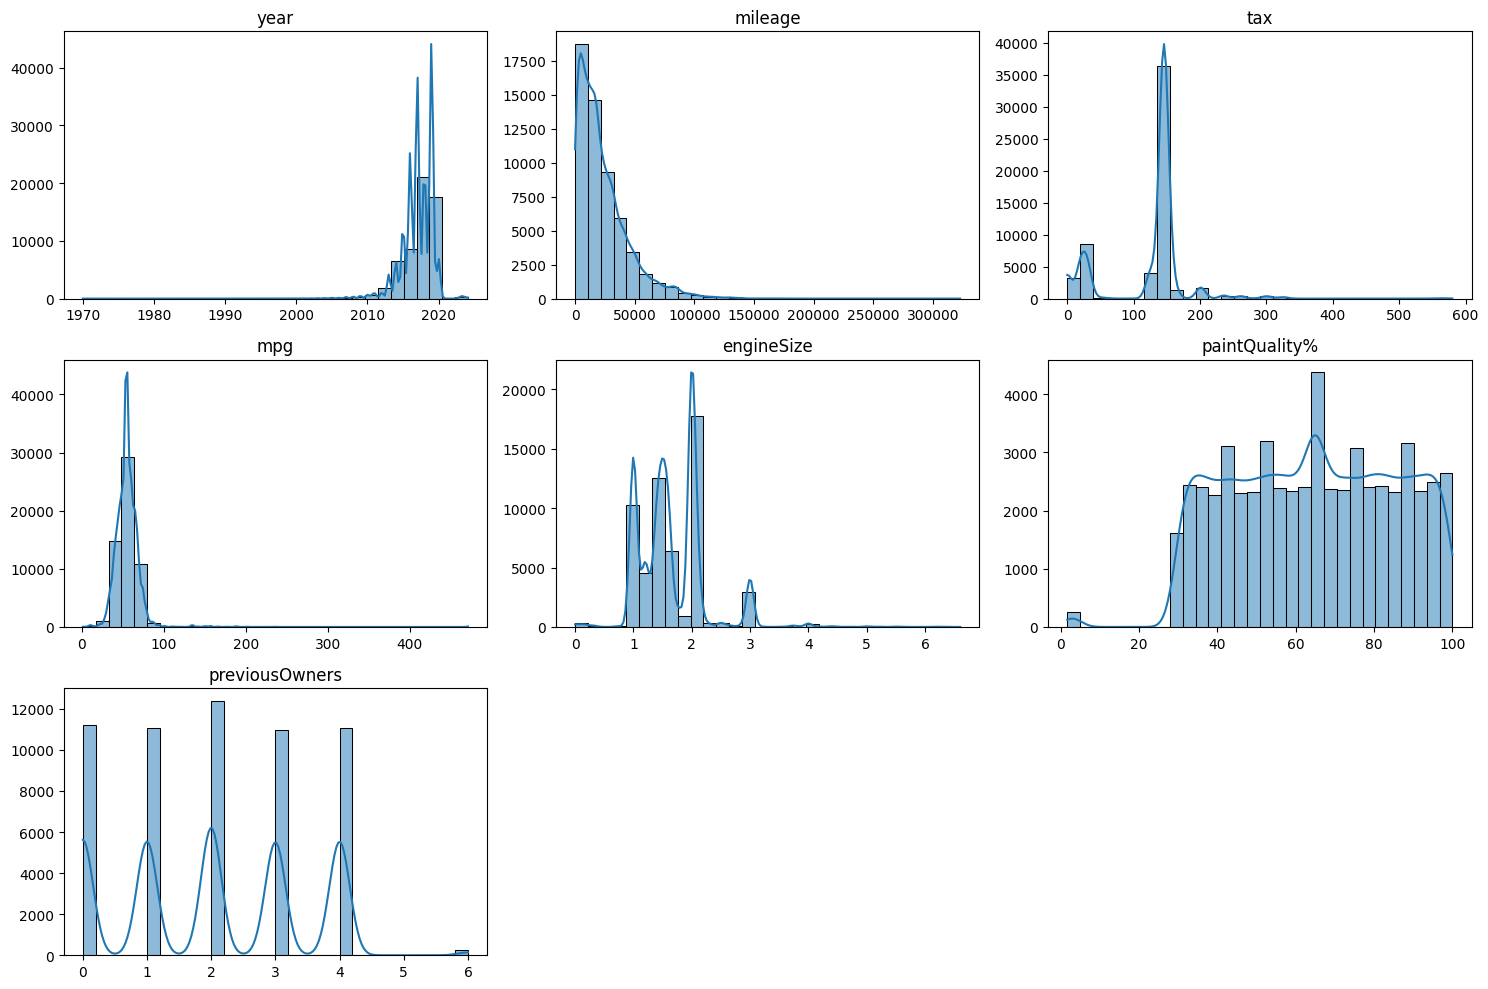

In [40]:
cat_cols_vis=plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.histplot(X_train[col], bins=30, kde=True)
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

From these plots , we noticed that
* Year:most of the cars are in recent years, with very few older models

* mileage: values are concentrated at low mileage with a long tail toward very high mileage

* tax: we notice a strong peak around specific values with some extreme high values

* mpg: most of the cars are in mid-range with a some very high outliers

* engineSize: explicit clusters at common engine sizes with fewer large engines

* PaintQuality%: Values are spread across the range

* previousOwners: Most of the values are between 0 and 4, with very few higher counts.

In [41]:
num_cols = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'paintQuality%']
skew_values = X_train[num_cols].skew().sort_values(ascending=False)
print("Skewness for numerical features:\n")
print(skew_values)

Skewness for numerical features:

mpg              8.125174
mileage          1.829081
engineSize       1.263691
tax             -0.001325
paintQuality%   -0.090407
year            -1.815101
dtype: float64


    Skewness Analysis
* mpg (8.12): Highly right-skewed distribution, indicating that most cars have moderate fuel efficiency while a few have extremely high values
* mileage (1.83):Right-skewed, as most cars have low to moderate mileage and few have very high mileage.
* engineSize (1.26):Right-skewed, reflecting that most cars have small engines and few have very large ones.
* tax (-0.00):Almost normal distribution.
* paintQuality% (-0.09):Nearly normal distribution with a very slight left skew , meaning cars have diverse paint conditions.
* year (-1.82): Left-skewed, as most cars are newer models while a few are much older

#####  Z-score

The Z-score method was chosen for this dataset because most numerical features (such as mileage, engineSize, tax, mpg, and year) are continuous and approximately normally distributed.

In [42]:
# Detecting and removing outliers using the Z-score method.
# Rows with any feature having |Z| > 3 are considered outliers and will be removed from the dataset.

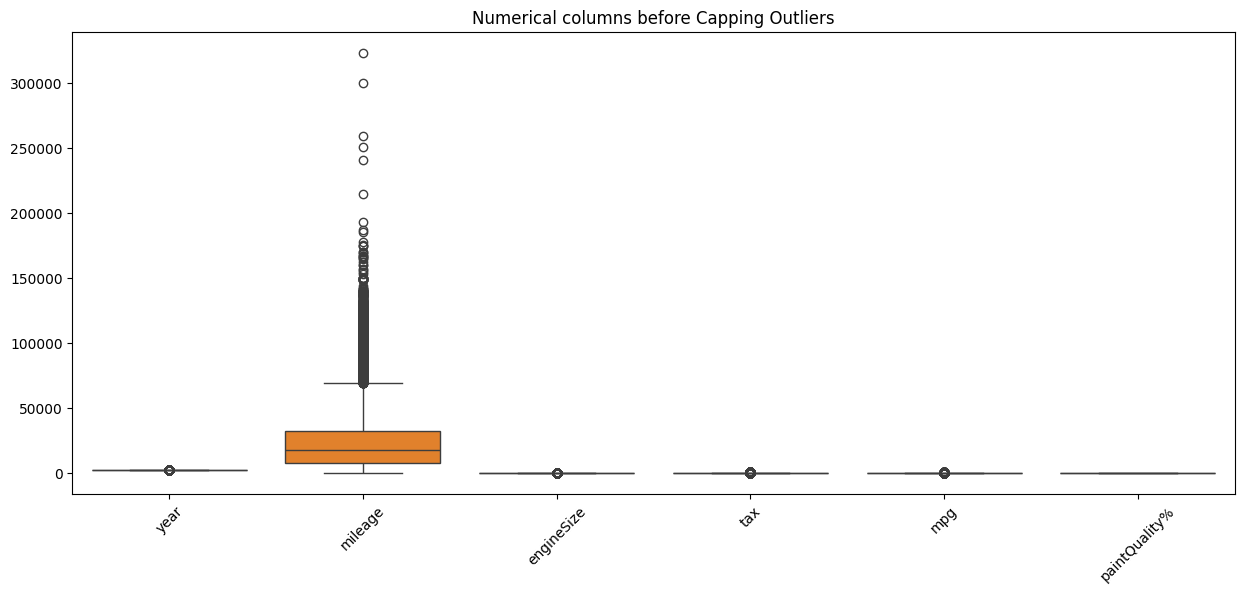

In [43]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_train[num_cols])
plt.title("Numerical columns before Capping Outliers")
plt.xticks(rotation=45)
plt.show()

* mileage: Shows a very wide spread with many outliers

* year: Tight range with a few outliers

* engineSize: Mostly compact values with some outliers

* tax: Narrow central range with some extreme points

* mpg: Most values are concentrated with some extreme points

* PaintQuality%: stable distribution

In [44]:
def cap_outliers(df, cols, threshold=3):
    for col in cols:
        z_scores = np.abs(stats.zscore(df[col]))
        upper = df[col].mean() + threshold * df[col].std()
        lower = df[col].mean() - threshold * df[col].std()
        df[col] = np.clip(df[col], lower, upper)
    return df

X_train = cap_outliers(X_train, num_cols)
X_val = cap_outliers(X_val, num_cols)
# Note: We don't cap test set outliers to avoid data leakage; handle if needed post-prediction.

print("Outliers capped in numerical columns.")

Outliers capped in numerical columns.


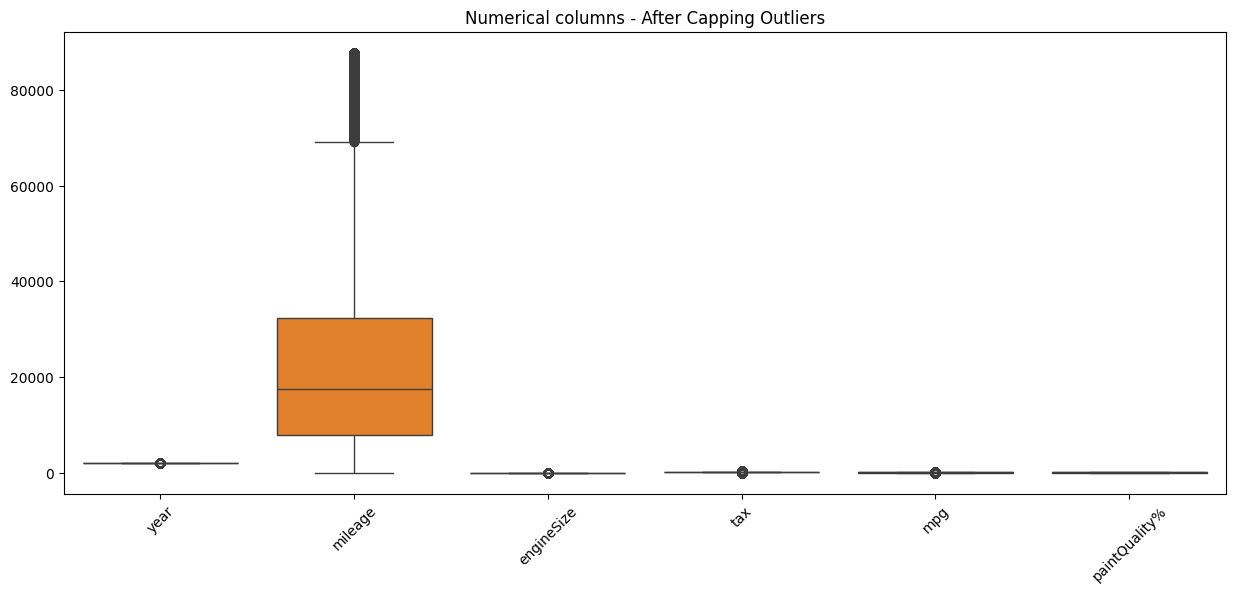

In [45]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_train[num_cols])
plt.title("Numerical columns - After Capping Outliers")
plt.xticks(rotation=45)
plt.show()

After capping , we can observe some explicit improvements in the data :
* Mileage: Extreme values are reduced and spread is more controlled while keeping variability

* year:minimal change

* engineSize: extreme values are limited

* tax: Outliers are constrained making the range more compact

* mpg: Extreme values are capped to reduce dispersion

### 4. Feature engineering

Feature engineering is the process of transforming raw data into meaningful features to improve machine learning model performance. Effective feature engineering helps enhance predictive accuracy, reduce overfitting, and optimize model outcomes. In this section, we will explore various techniques and their impact on improving machine learning models.

In [46]:
X_train

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
56692,VW,Other,2016.0,Manual,12769.0,Petrol,20.0,94.78638,1.2,93.0,0.0,0.0
34259,Mercedes,Other,2019.0,Semi-Auto,11412.0,Petrol,145.0,45.60000,1.5,55.0,1.0,0.0
49806,VW,Other,2017.0,Manual,40900.0,Unknown,0.0,74.30000,1.6,44.0,1.0,0.0
170,Ford,Other,2019.0,Manual,10000.0,Diesel,145.0,54.30000,1.5,80.0,0.0,0.0
17164,Ford,Other,2017.0,Manual,21136.0,Petrol,145.0,54.30000,1.0,34.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Other,Other,2019.0,Semi-Auto,7119.0,Diesel,145.0,39.20000,2.2,39.0,0.0,0.0
6265,Ford,Other,2017.0,Manual,19512.0,Petrol,145.0,54.30000,1.0,40.0,2.0,0.0
54886,Toyota,Other,2019.0,Automatic,2984.0,Hybrid,135.0,49.60000,2.5,93.0,4.0,0.0
860,Skoda,Other,2016.0,Manual,32326.0,Petrol,20.0,54.30000,1.0,41.0,3.0,0.0


##### 4.1 Creating New Features

We will now try to find new features that will help us improve our data quality

We added some new features that we believe make sense and add value and relevance to our data

In [47]:
#1. car_age
X_train['age'] = (2025 - X_train['year'])

**visualisation**

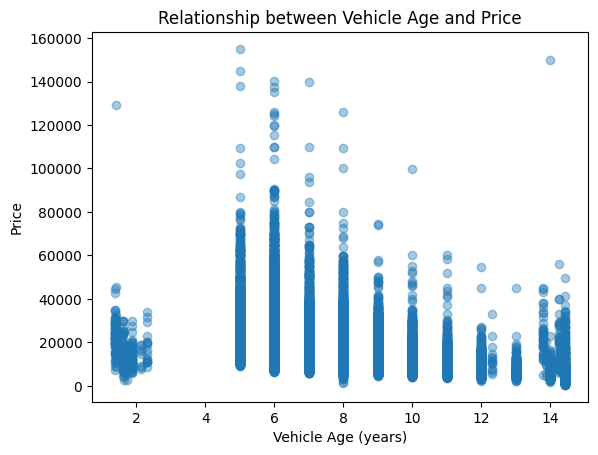

In [48]:
plt.figure()
plt.scatter(X_train['age'], y_train, alpha=0.4)
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Price")
plt.title("Relationship between Vehicle Age and Price")
plt.show()

Relationship between vehicle age and price. Older vehicles tend to have lower prices, confirming the expected depreciation effect.

In [49]:
#2. Annual Mileage: df['age'] = 2025 - df['year']
X_train['mileage_per_year'] = X_train['mileage'] / (X_train['age'] + 1)

**visualisation**

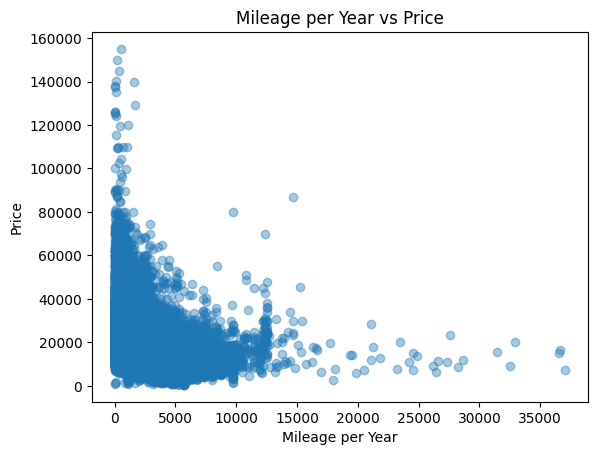

In [50]:
plt.figure()
plt.scatter(X_train['mileage_per_year'], y_train, alpha=0.4)
plt.xlabel("Mileage per Year")
plt.ylabel("Price")
plt.title("Mileage per Year vs Price")
plt.show()

Mileage per year versus price. Higher annual usage is associated with lower vehicle prices

In [51]:
#3. Luxury/Premium Indicator:
premium_brands = ['Audi', 'BMW', 'Mercedes', 'VW']
X_train['is_premium_brand'] = X_train['Brand'].isin(premium_brands).astype(int)

**visualisation**

In [52]:
X_train['is_premium_brand'].unique()


array([1, 0])

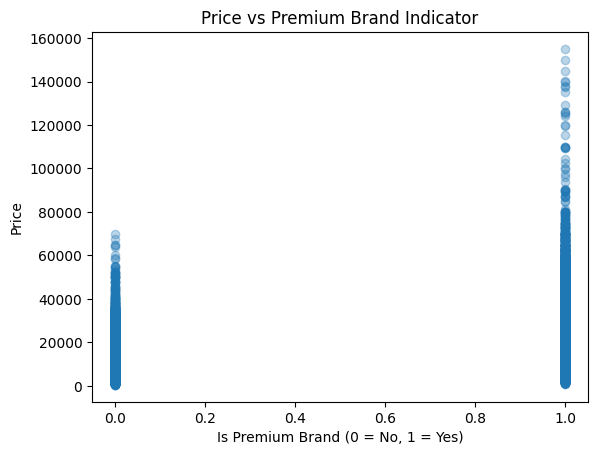

In [53]:
plt.figure()
plt.scatter(X_train['is_premium_brand'], y_train, alpha=0.3)
plt.xlabel("Is Premium Brand (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.title("Price vs Premium Brand Indicator")
plt.show()

Price distribution by brand category. Premium brands exhibit higher median prices, justifying the inclusion of a premium brand indicator.

In [54]:
#4. Performance Efficiency Proxy:
X_train['performance_ratio'] = X_train['engineSize'] / X_train['mpg']

In [55]:
X_train

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,age,mileage_per_year,is_premium_brand,performance_ratio
56692,VW,Other,2016.0,Manual,12769.0,Petrol,20.0,94.78638,1.2,93.0,0.0,0.0,9.0,1276.900000,1,0.012660
34259,Mercedes,Other,2019.0,Semi-Auto,11412.0,Petrol,145.0,45.60000,1.5,55.0,1.0,0.0,6.0,1630.285714,1,0.032895
49806,VW,Other,2017.0,Manual,40900.0,Unknown,0.0,74.30000,1.6,44.0,1.0,0.0,8.0,4544.444444,1,0.021534
170,Ford,Other,2019.0,Manual,10000.0,Diesel,145.0,54.30000,1.5,80.0,0.0,0.0,6.0,1428.571429,0,0.027624
17164,Ford,Other,2017.0,Manual,21136.0,Petrol,145.0,54.30000,1.0,34.0,4.0,0.0,8.0,2348.444444,0,0.018416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Other,Other,2019.0,Semi-Auto,7119.0,Diesel,145.0,39.20000,2.2,39.0,0.0,0.0,6.0,1017.000000,0,0.056122
6265,Ford,Other,2017.0,Manual,19512.0,Petrol,145.0,54.30000,1.0,40.0,2.0,0.0,8.0,2168.000000,0,0.018416
54886,Toyota,Other,2019.0,Automatic,2984.0,Hybrid,135.0,49.60000,2.5,93.0,4.0,0.0,6.0,426.285714,0,0.050403
860,Skoda,Other,2016.0,Manual,32326.0,Petrol,20.0,54.30000,1.0,41.0,3.0,0.0,9.0,3232.600000,0,0.018416


We will now apply the same feature engineering steps to the validation and test tables

In [56]:
X_val['age'] = (2025 - X_val['year'])
X_val['mileage_per_year'] = X_val['mileage'] / (X_val['age'] + 1)

X_val['performance_ratio'] = X_val['engineSize'] / X_val['mpg']

X_val['is_premium_brand'] = X_val['Brand'].isin(premium_brands).astype(int)

In [57]:
X_test['age'] = (2025 - X_test['year'])

X_test['mileage_per_year'] = X_test['mileage'] / (X_test['age'] + 1)

X_test['performance_ratio'] = X_test['engineSize'] / X_test['mpg']

X_test['is_premium_brand'] = X_test['Brand'].isin(premium_brands).astype(int)

##### 4.2 Encoding  Categorical Variables and Scaling Numerical Variables

Encoding transforms categorical data into numerical format for use in machine learning models.


##### Categorical variables encoding

In [58]:
def target_encode_fit(X_train, y_train, cat_cols, smoothing=5):
    """Calculate mean target value for each category"""
    global_mean = y_train.mean()
    target_mappings = {}

    for col in cat_cols:
        # Calculate mean and count for each category
        category_stats = pd.DataFrame({
            'mean': y_train.groupby(X_train[col]).mean(),
            'count': y_train.groupby(X_train[col]).count()
        })

        # Apply smoothing
        category_stats['smoothed_mean'] = (
            (category_stats['mean'] * category_stats['count'] + global_mean * smoothing) /
            (category_stats['count'] + smoothing)
        )

        target_mappings[col] = category_stats['smoothed_mean'].to_dict()

    return target_mappings, global_mean

def target_encode_transform(X, target_mappings, global_mean, cat_cols):
    """Transform categorical columns using target encoding"""
    X_encoded = X.copy()

    for col in cat_cols:
        X_encoded[col] = X[col].map(target_mappings[col]).fillna(global_mean)

    return X_encoded

In [59]:
# Fit target encoding on training data
target_mappings, global_mean = target_encode_fit(X_train, y_train, cat_cols, smoothing=5)

# Transform train, val, and test
X_train = target_encode_transform(X_train, target_mappings, global_mean, cat_cols)
X_val = target_encode_transform(X_val, target_mappings, global_mean, cat_cols)
X_test = target_encode_transform(X_test, target_mappings, global_mean, cat_cols)

print(f" Target encoding complete")
print(f"  Categorical columns encoded: {len(cat_cols)}")

 Target encoding complete
  Categorical columns encoded: 5


Let's see the distribution of encoded values by creating a boxplot

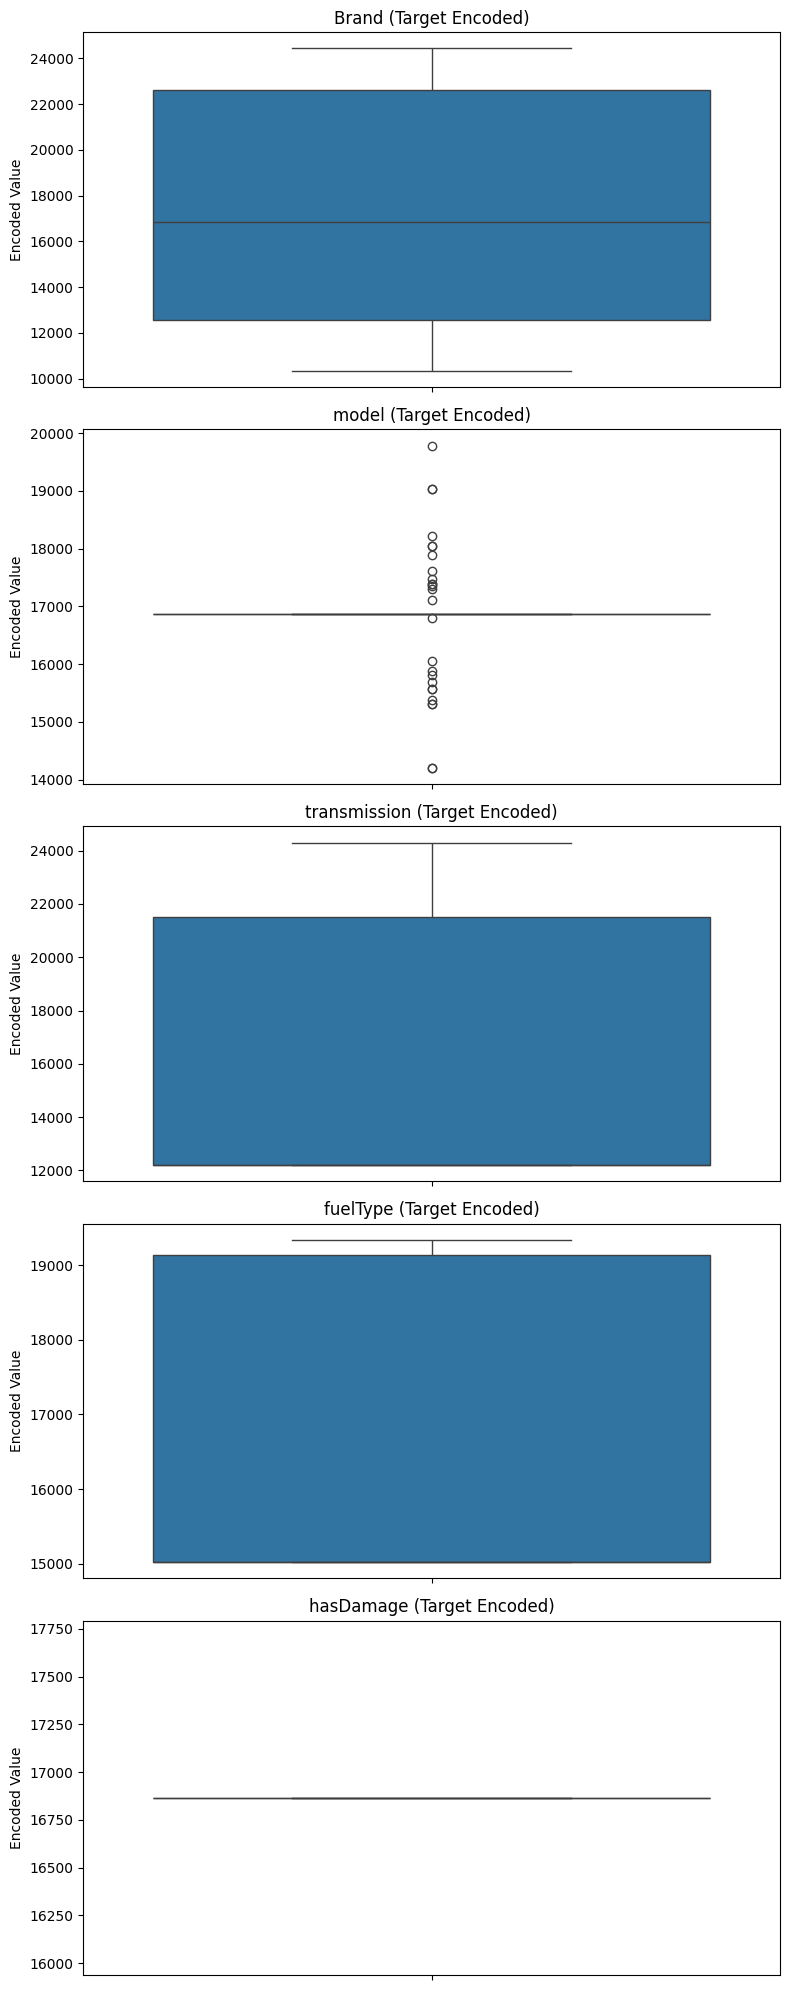

In [60]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(8, 4*len(cat_cols)))

for i, col in enumerate(cat_cols):
    sns.boxplot(y=X_train[col], ax=axes[i])
    axes[i].set_title(col + " (Target Encoded)")
    axes[i].set_ylabel("Encoded Value")

plt.tight_layout()
plt.show()

In [61]:
X_train

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,age,mileage_per_year,is_premium_brand,performance_ratio
56692,16866.739559,16864.85286,2016.0,12205.221343,12769.0,15023.833671,20.0,94.78638,1.2,93.0,0.0,16864.986889,9.0,1276.900000,1,0.012660
34259,24437.340174,16864.85286,2019.0,24303.499278,11412.0,15023.833671,145.0,45.60000,1.5,55.0,1.0,16864.986889,6.0,1630.285714,1,0.032895
49806,16866.739559,16864.85286,2017.0,12205.221343,40900.0,16903.873000,0.0,74.30000,1.6,44.0,1.0,16864.986889,8.0,4544.444444,1,0.021534
170,12577.888600,16864.85286,2019.0,12205.221343,10000.0,19142.618183,145.0,54.30000,1.5,80.0,0.0,16864.986889,6.0,1428.571429,0,0.027624
17164,12577.888600,16864.85286,2017.0,12205.221343,21136.0,15023.833671,145.0,54.30000,1.0,34.0,4.0,16864.986889,8.0,2348.444444,0,0.018416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,16986.797033,16864.85286,2019.0,24303.499278,7119.0,19142.618183,145.0,39.20000,2.2,39.0,0.0,16864.986889,6.0,1017.000000,0,0.056122
6265,12577.888600,16864.85286,2017.0,12205.221343,19512.0,15023.833671,145.0,54.30000,1.0,40.0,2.0,16864.986889,8.0,2168.000000,0,0.018416
54886,12554.505043,16864.85286,2019.0,21500.611354,2984.0,19342.969858,135.0,49.60000,2.5,93.0,4.0,16864.986889,6.0,426.285714,0,0.050403
860,14199.567789,16864.85286,2016.0,12205.221343,32326.0,15023.833671,20.0,54.30000,1.0,41.0,3.0,16864.986889,9.0,3232.600000,0,0.018416


##### Numerical variables scaling  

In [62]:
num_cols.extend(['age', 'mileage_per_year', 'performance_ratio', 'is_premium_brand'])

In [63]:
X_train[num_cols]

,year,mileage,engineSize,tax,mpg,paintQuality%,age,mileage_per_year,performance_ratio,is_premium_brand
56692,2016.0,12769.0,1.2,20.0,94.78638,93.0,9.0,1276.900000,0.012660,1
34259,2019.0,11412.0,1.5,145.0,45.60000,55.0,6.0,1630.285714,0.032895,1
49806,2017.0,40900.0,1.6,0.0,74.30000,44.0,8.0,4544.444444,0.021534,1
170,2019.0,10000.0,1.5,145.0,54.30000,80.0,6.0,1428.571429,0.027624,0
17164,2017.0,21136.0,1.0,145.0,54.30000,34.0,8.0,2348.444444,0.018416,0
...,...,...,...,...,...,...,...,...,...,...
37194,2019.0,7119.0,2.2,145.0,39.20000,39.0,6.0,1017.000000,0.056122,0
6265,2017.0,19512.0,1.0,145.0,54.30000,40.0,8.0,2168.000000,0.018416,0
54886,2019.0,2984.0,2.5,135.0,49.60000,93.0,6.0,426.285714,0.050403,0
860,2016.0,32326.0,1.0,20.0,54.30000,41.0,9.0,3232.600000,0.018416,0


Since all our features are numerical values, our preprocessing only requires scaling, not one-hot or label encoding

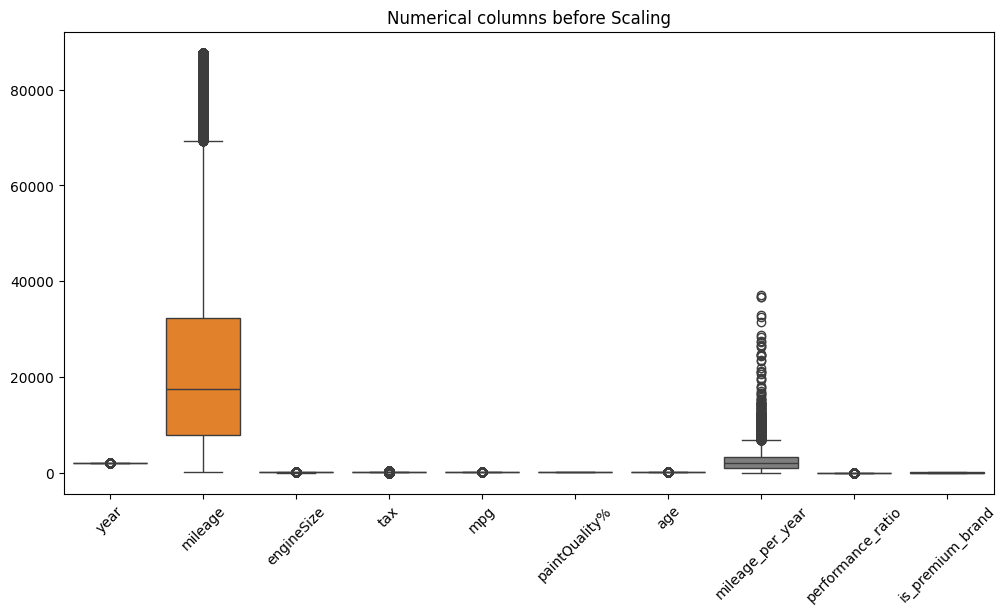

In [64]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train[num_cols])
plt.xticks(rotation=45)
plt.title("Numerical columns before Scaling")
plt.show()

Robust Scaler

In [65]:
scaler = RobustScaler()

# Fit
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Quick check
print("Scaled shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# Optional: preview
X_train.head()

Scaled shapes:
Train: (56974, 16)
Val: (18992, 16)
Test: (32567, 16)


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,age,mileage_per_year,is_premium_brand,performance_ratio
56692,16866.739559,16864.85286,-0.333333,12205.221343,-0.193816,15023.833671,-6.25,2.831215,-0.500,0.800000,0.0,16864.986889,0.333333,-0.315646,1.0,-1.078271
34259,24437.340174,16864.85286,0.666667,24303.499278,-0.249059,15023.833671,0.00,-0.608392,-0.125,-0.285714,1.0,16864.986889,-0.666667,-0.164177,1.0,0.219993
49806,16866.739559,16864.85286,0.000000,12205.221343,0.951373,16903.873000,-7.25,1.398601,0.000,-0.600000,1.0,16864.986889,0.000000,1.084891,1.0,-0.508895
170,12577.888600,16864.85286,0.666667,12205.221343,-0.306540,19142.618183,0.00,0.000000,-0.125,0.428571,0.0,16864.986889,-0.666667,-0.250636,0.0,-0.118159
17164,12577.888600,16864.85286,0.000000,12205.221343,0.146797,15023.833671,0.00,0.000000,-0.750,-0.885714,4.0,16864.986889,0.000000,0.143640,0.0,-0.708954


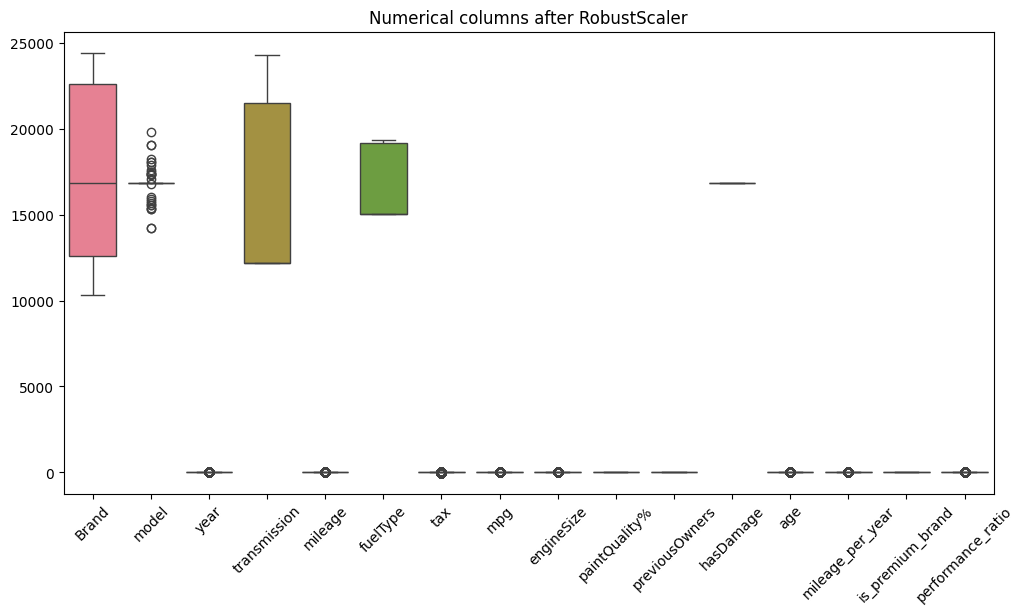

In [66]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train)
plt.xticks(rotation=45)
plt.title("Numerical columns after RobustScaler")
plt.show()

After scaling our numerical features, We notice that the distributions are better

#### 4.2 Feature selection





Now is the best time to apply feature selection in order to retain only the most relevant variables for model training

Since we have multiple feature selection techniques (filter, wrapper, and embedded methods), we will be applying each of them and later, in Section 4.2.4, select the most relevant features we will be keeping for our model training

##### 4.2.1 Filter methods

Filter-based methods evaluate the relevance of features independently of the model using statistical measures such as correlation. This section explores how these methods help reduce dimensionality, improve model performance, and prevent overfitting by selecting the most informative features.

##### 4.2.1.1  Constant variables

Before modeling, we check for constant features, as variables with no variation across observations do not carry useful information for prediction

hasDamage Column

In [67]:
var_table = (
    X_train.var()
    .rename("Variance")
    .to_frame()
    .round(4)
    .sort_values("Variance", ascending=False)
)

var_table



,Variance
transmission,2.841779e+07
Brand,2.689628e+07
fuelType,4.124371e+06
model,9.542086e+02
tax,8.755600e+00
previousOwners,2.028100e+00
performance_ratio,1.344500e+00
mileage_per_year,6.828000e-01
mpg,6.737000e-01
mileage,6.726000e-01


In [68]:
X_train.drop(columns=['hasDamage'], inplace=True)
X_val.drop(columns=['hasDamage'], inplace=True)
X_test.drop(columns=['hasDamage'], inplace=True)

Here we found that hasdamage feature is constant . Thus we removed it.
In fact, constant variables are dropped since they contain no variance and have no effect on the machine learning algorithms we will work on


##### 4.2.1.2 Correlation Indecies : (Redudant Variable)

Before applying feature selection methods, a correlation analysis is also conducted to identify highly correlated variables in order to avoid redundancy and multicollinearity

In [69]:
def cor_heatmap(cor):
    annot_matrix = cor.round(2).astype(str).where(np.abs(cor) >= 0.3, "")

    plt.figure(figsize=(12,10))
    sns.heatmap(data=cor,
                annot=annot_matrix,
                fmt='s',
                cmap=plt.cm.Reds,
                linewidths=.5,
                square=True)
    plt.show()

In [70]:
cor_spearman = X_train.corr(method ='spearman')
cor_spearman

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,age,mileage_per_year,is_premium_brand,performance_ratio
Brand,1.000000,0.017333,0.078289,0.512761,-0.040370,0.275809,0.054723,-0.058147,0.513991,0.001691,-0.002127,-0.078289,-0.031645,0.854821,0.398609
model,0.017333,1.000000,0.003253,0.013680,-0.003951,0.010973,-0.000764,0.000179,0.012492,0.003193,-0.004103,-0.003253,-0.003485,0.011566,0.009850
year,0.078289,0.003253,1.000000,0.179289,-0.768549,-0.105414,0.303049,-0.294246,-0.040285,0.004459,0.002995,-1.000000,-0.654243,0.066563,0.116068
transmission,0.512761,0.013680,0.179289,1.000000,-0.152891,0.271065,0.158748,-0.199534,0.494920,0.001279,-0.000382,-0.179289,-0.137584,0.455869,0.464122
mileage,-0.040370,-0.003951,-0.768549,-0.152891,1.000000,0.190404,-0.241331,0.304030,0.096543,-0.002400,0.000724,0.768549,0.982454,-0.033395,-0.079943
fuelType,0.275809,0.010973,-0.105414,0.271065,0.190404,1.000000,-0.150684,0.340151,0.601163,-0.002161,0.004580,0.105414,0.196611,0.245253,0.265028
tax,0.054723,-0.000764,0.303049,0.158748,-0.241331,-0.150684,1.000000,-0.536712,0.145647,0.001104,-0.000701,-0.303049,-0.210941,0.053300,0.385050
mpg,-0.058147,0.000179,-0.294246,-0.199534,0.304030,0.340151,-0.536712,1.000000,-0.182611,0.002192,0.000200,0.294246,0.293105,-0.112459,-0.652212
engineSize,0.513991,0.012492,-0.040285,0.494920,0.096543,0.601163,0.145647,-0.182611,1.000000,0.002313,0.008850,0.040285,0.099345,0.489717,0.839483
paintQuality%,0.001691,0.003193,0.004459,0.001279,-0.002400,-0.002161,0.001104,0.002192,0.002313,1.000000,-0.001936,-0.004459,-0.001589,-0.000019,0.001294


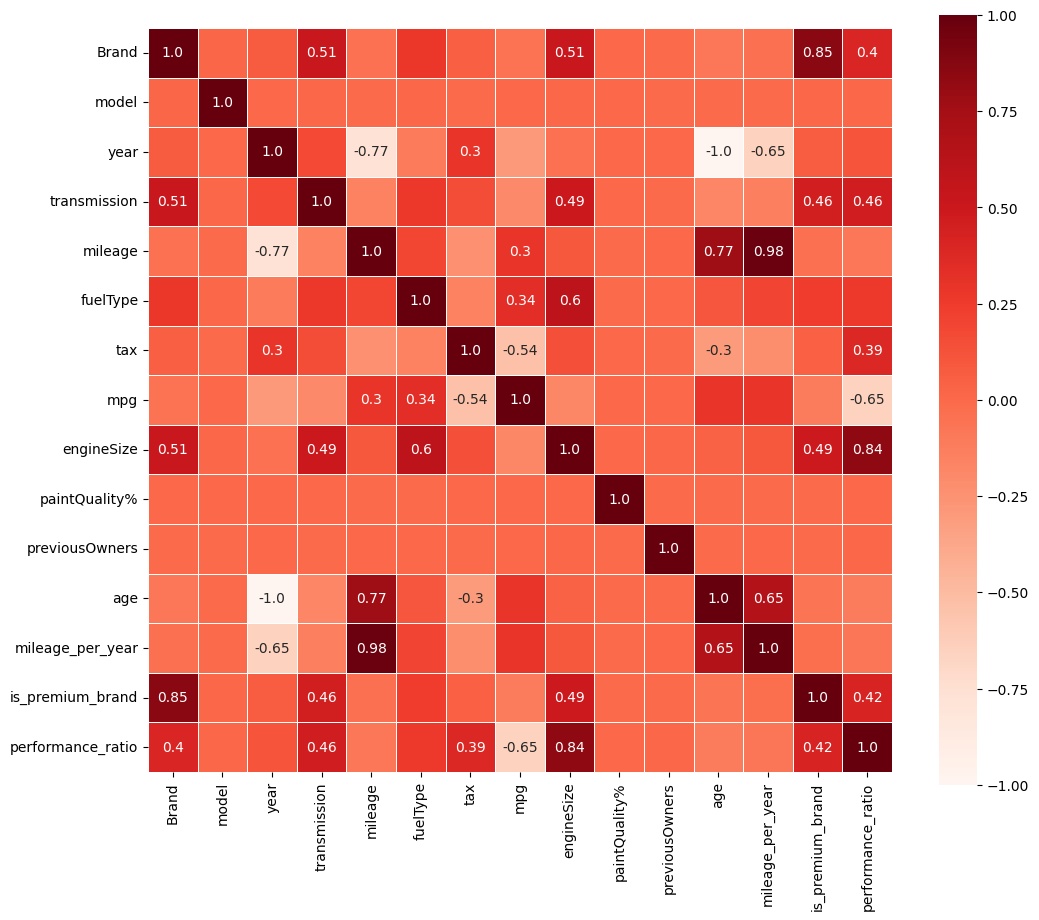

In [71]:
cor_heatmap(cor_spearman)

The correlation analysis revealed strong dependencies between several original and engineered features. In particular, `year` and `age` exhibit a perfect negative correlation (ρ = −1.00), confirming that they convey identical information. Similarly, `mileage` is strongly correlated with `age` (ρ ≈ 0.80), and `mileage_per_year` shows a high correlation with both `age` (ρ ≈ 0.70) and `mileage` (ρ ≈ 1.00).  

In addition, the engineered `performance_ratio` feature is highly correlated with `engineSize` (ρ ≈ 0.80) and strongly negatively correlated with `mpg` (ρ ≈ −0.70), indicating redundancy with existing engine-related variables.  

A strong correlation was observed between the engineered binary feature `is_premium_brand` and the original `Brand` variable (ρ = 0.85), which is expected . To avoid redundancy and reduce model complexity, the original `Brand` feature will be  removed, while retaining `is_premium_brand` as a more interpretable representation of brand category.


In [72]:
# We will list here the redundant features deducted from the correlation heatmap
features_correlated = [
    'year',                # perfectly correlated with age (ρ = -1.00)
    'mileage_per_year',    # highly correlated with mileage and age
    'performance_ratio',   # highly correlated with engineSize and mpg
    'Brand'
]
features = X_train.columns.tolist()

correlation_decision = [
    0 if f in features_correlated else 1
    for f in features
]

Even though this correlation heatmap gives us the highly correlated features , we still need to use other feature selection techniques to get more insights.
The reason we do this is that we now that a high correlation between two variables does not necessarily mean that one variable causes the other to change. It simply indicates that there is a relationship between the two variables.


As an alternative to that ,We need to find some way as an untie mechanism - out of theses variables which one (if any at all, should be removed). One possible approach could be to use other techniques of feature selection to decide which variables  we should keep

##### 4.2.2 Wrapper  method (RFE )

Unlike filter methods, which assess features independently, wrapper methods evaluate the effectiveness of feature subsets by measuring the model’s performance, making them more computationally expensive but often more accurate in selecting relevant features.

We changed Feature selection Method to RFE

In [73]:
X_val = X_val[X_train.columns]
X_test = X_test[X_train.columns]

In [74]:
nof_list = np.arange(1, X_train.shape[1] + 1)
high_score = -np.inf
optimal_nof = 0

train_score_list = []
val_score_list = []
for n in nof_list:

    model = LinearRegression()

    rfe = RFE(
        estimator=model,
        n_features_to_select=n
    )

    X_train_rfe = rfe.fit_transform(X_train, y_train)
    X_val_rfe= rfe.transform(X_val)
    model.fit(X_train_rfe, y_train)

    # Training performance
    train_score = r2_score(y_train, model.predict(X_train_rfe))
    train_score_list.append(train_score)

    # Validation performance
    val_score = r2_score(y_val, model.predict(X_val_rfe))
    val_score_list.append(val_score)

    # Track best model
    if val_score > high_score:
        high_score = val_score
        optimal_nof = n

print(f"Optimal number of features: {optimal_nof}")
print(f"Best validation R²: {high_score:.4f}")

Optimal number of features: 15
Best validation R²: 0.7388


In [75]:
model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=optimal_nof)
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Get the selected feature names
selected_rfe = X_train.columns[rfe.support_].tolist()
print("Selected features (RFE):", selected_rfe)

# Create the rfe_decision list for your decision table
rfe_decision = [1 if f in selected_rfe else 0 for f in features]

Selected features (RFE): ['Brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'age', 'mileage_per_year', 'is_premium_brand', 'performance_ratio']


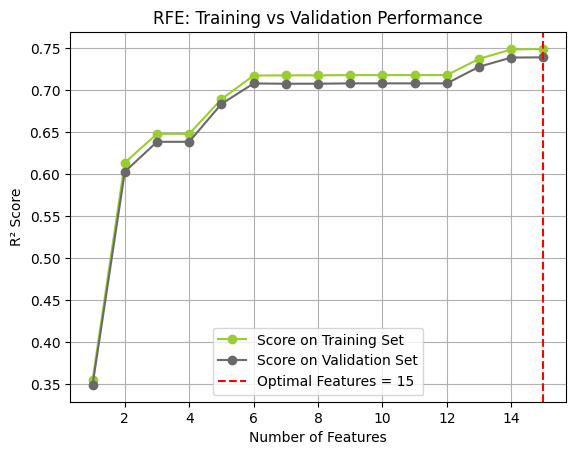

In [76]:
plt.plot(nof_list, train_score_list, label="Score on Training Set", color='yellowgreen', marker='o')
plt.plot(nof_list, val_score_list, label="Score on Validation Set", color='dimgray', marker='o')

# Highlight the optimal number of features
plt.axvline(optimal_nof, color='red', linestyle='--', label=f'Optimal Features = {optimal_nof}')

plt.xlabel("Number of Features")
plt.ylabel("R² Score")
plt.title("RFE: Training vs Validation Performance")
plt.legend()
plt.grid(True)
plt.show()

##### 4.2.3 Embedded  method

These methods use algorithms that inherently select features as part of the model’s learning process. Embedded methods are computationally efficient and tend to be more accurate than filter methods, as they consider feature interactions and model performance simultaneously.

**Least Absolute Shrinkage and Selection Operator (LASSO)**

In [77]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8,10))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.show()

In [78]:
reg = LassoCV()
reg.fit(X_train, y_train)
coef = pd.Series(reg.coef_, index = X_train.columns)
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 2 variables and eliminated the other 13 variables


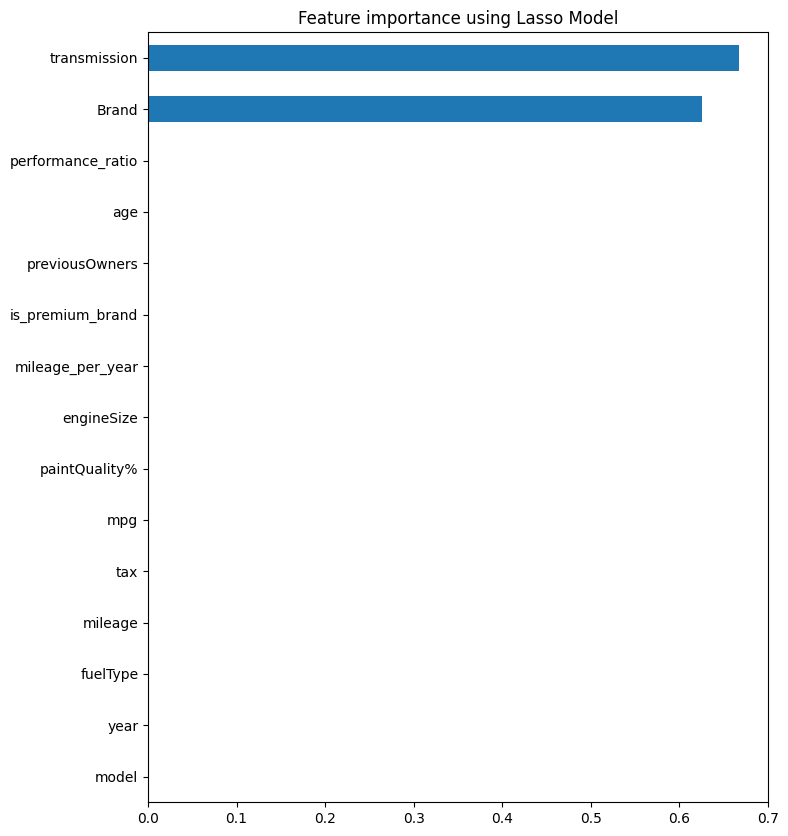

In [79]:
plot_importance(coef,'Lasso')


In [80]:
lasso_decision = [1 if coef[f] != 0 else 0 for f in features]

print("Selected features by Lasso:")
print(coef[coef != 0].index.tolist())

Selected features by Lasso:
['Brand', 'transmission']


**Feature importance following Decision tree**

In [81]:


# A single tree uses much less memory
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

importances = pd.Series(tree_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print("Feature Importances (Decision Tree):")
print(importances)

Feature Importances (Decision Tree):
mileage              0.158946
performance_ratio    0.145208
mileage_per_year     0.134158
paintQuality%        0.104946
mpg                  0.097387
Brand                0.087716
engineSize           0.049050
previousOwners       0.044613
transmission         0.040495
year                 0.039485
tax                  0.038206
age                  0.030349
fuelType             0.021410
is_premium_brand     0.008030
model                0.000000
dtype: float64


In [82]:
threshold = importances.mean()
# Binary decision
tree_decision = [
    1 if importances[f] >= threshold else 0
    for f in features
]
print("Decision Tree selected features:")
print(importances[importances >= threshold].index.tolist())

Decision Tree selected features:
['mileage', 'performance_ratio', 'mileage_per_year', 'paintQuality%', 'mpg', 'Brand']


### 4.2.4 Final features

Now that we have different perspectives, we will make a table that summarise which features to keep according to three methods of feature selection : filter, embedded and wrapper methods

In [83]:
final_decision = [
    1 if (c == 1 and (l == 1 or r == 1 or t == 1)) else 0
    for c, l, r, t in zip(correlation_decision,lasso_decision, rfe_decision, tree_decision)
]

# Show selected features
selected_features = [feature for feature, decision in zip(features, final_decision) if decision == 1]
print(f"Final selected features ({len(selected_features)} out of {len(features)}):")
print(selected_features)

Final selected features (11 out of 15):
['model', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'age', 'is_premium_brand']


In [84]:
decision_table = pd.DataFrame({
    "Feature": features,
    "Filter Method": correlation_decision,
    "Wrapper Method": rfe_decision,
    "Embedded Method" : lasso_decision,
    "Decision Tree": tree_decision,
    "Final Decision": final_decision
})

decision_table = decision_table.replace({1: "Keep", 0: "Discard"})
decision_table

,Feature,Filter Method,Wrapper Method,Embedded Method,Decision Tree,Final Decision
0,Brand,Discard,Keep,Keep,Keep,Discard
1,model,Keep,Keep,Discard,Discard,Keep
2,year,Discard,Keep,Discard,Discard,Discard
3,transmission,Keep,Keep,Keep,Discard,Keep
4,mileage,Keep,Keep,Discard,Keep,Keep
5,fuelType,Keep,Keep,Discard,Discard,Keep
6,tax,Keep,Keep,Discard,Discard,Keep
7,mpg,Keep,Keep,Discard,Keep,Keep
8,engineSize,Keep,Keep,Discard,Discard,Keep
9,paintQuality%,Keep,Keep,Discard,Keep,Keep


### **Key Decisions**
The final feature set retains model, transmission, mileage, fuelType, mpg, paintQuality%, tax, engineSize, previousOwners, age, is_premium_brand, and related performance indicators, as these variables were consistently supported by filter, wrapper, and embedded methods, while Brand, year, mileage_per_year, and performance_ratio were discarded due to limited or inconsistent predictive contribution.


#### 5. Model Training

We will now compare different model performances to predict the price of the cars and later on choose the best fit for our car prediction problem

##### 5.1 Ridge Regression

In [85]:
X_train_sel= X_train[selected_features]
X_val_sel  = X_val[selected_features]

In [86]:
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train_sel, y_train)

y_train_pred = model.predict(X_train_sel)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Predict on validation set
y_val_pred = model.predict(X_val_sel)



    Model Evaluation

In [87]:
mse_ridge_train = mean_squared_error(y_val, y_val_pred)
mse_ridge_val = mean_squared_error(y_val, y_val_pred)
rmse_ridge_train = np.sqrt(mse_ridge_train)
rmse_ridge_val = np.sqrt(mse_ridge_val)
r2_ridge_train = r2_score(y_train, y_train_pred)
r2_ridge = r2_score(y_val, y_val_pred)

print("RIDGE RESULTS (Final Feature Set)")
print(f"{'='*60}")
print(f"  R² train: {r2_ridge_train:.4f}")
print(f"  R² val:   {r2_ridge:.4f}")
print(f"  MSE:  {mse_ridge_val:,.2f}")
print(f"  RMSE: {rmse_ridge_val:,.2f}")
print(f"  Features used: {len(selected_features)}")
print(f"{'='*60}")

RIDGE RESULTS (Final Feature Set)
  R² train: 0.7170
  R² val:   0.7091
  MSE:  28,194,750.65
  RMSE: 5,309.87
  Features used: 11


    Visualising the difference between Actual and Predicted Values




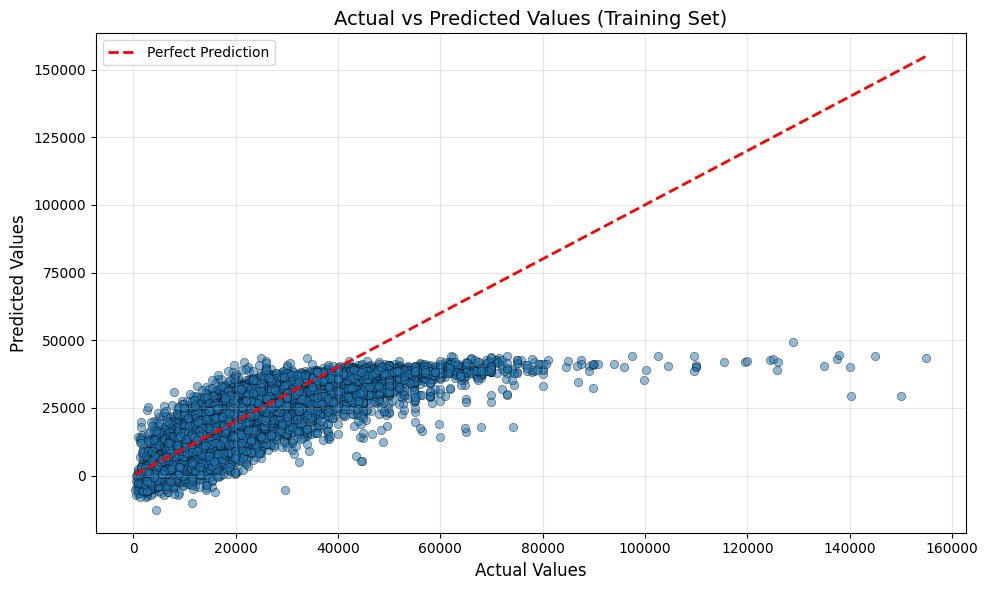

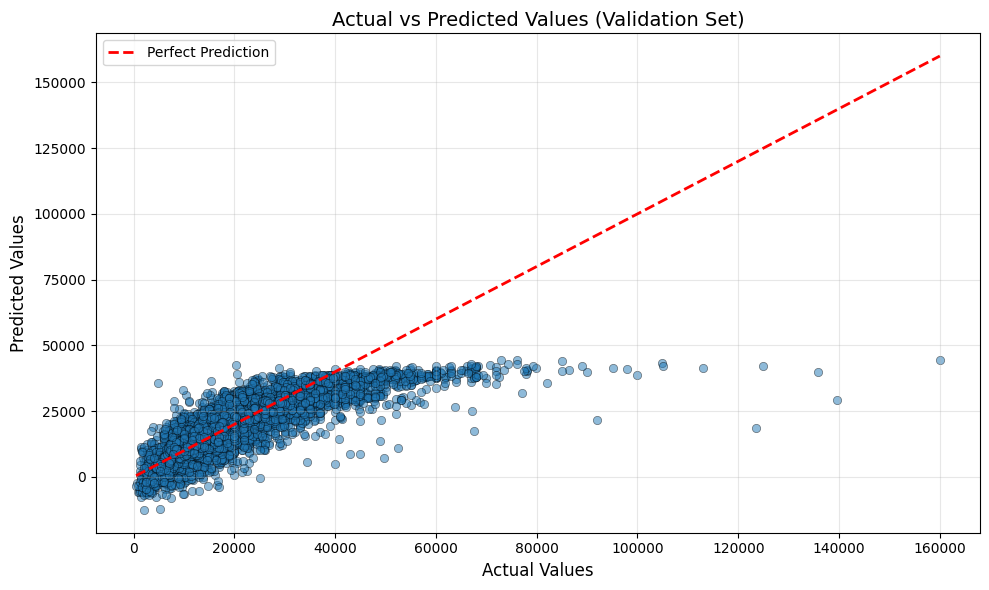

In [88]:
y_train_pred = model.predict(X_train_sel)

# TRAIN scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Actual vs Predicted Values (Training Set)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# VAL scatter plot
y_val_pred = model.predict(X_val_sel)

plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_val_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Actual vs Predicted Values (Validation Set)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This plot tells us that :

* Low values (0 to ~30,000): Most blue dots are very close to or right on the red line
    The model is very accurate for lower-value items.
* Medium values (~30,000 to ~80,000): Dots are still fairly close to the line, but with a little more spread.
    Predictions are acceptable but not as perfect as for low values
* High values (above ~80,000): Dots are mostly below the red line and spread out more. There are also fewer dots here.
    The model under-predicts high-value items

Also , the training set plot is almost identical to this validation set plot
* Same performance on different values (high performance on low values, slight
scatter in medium values, under-prediction and wider spread on high values)

To understand better, we will also create another figure to compare between the actual and predicted values by making it easier to see individual examples:

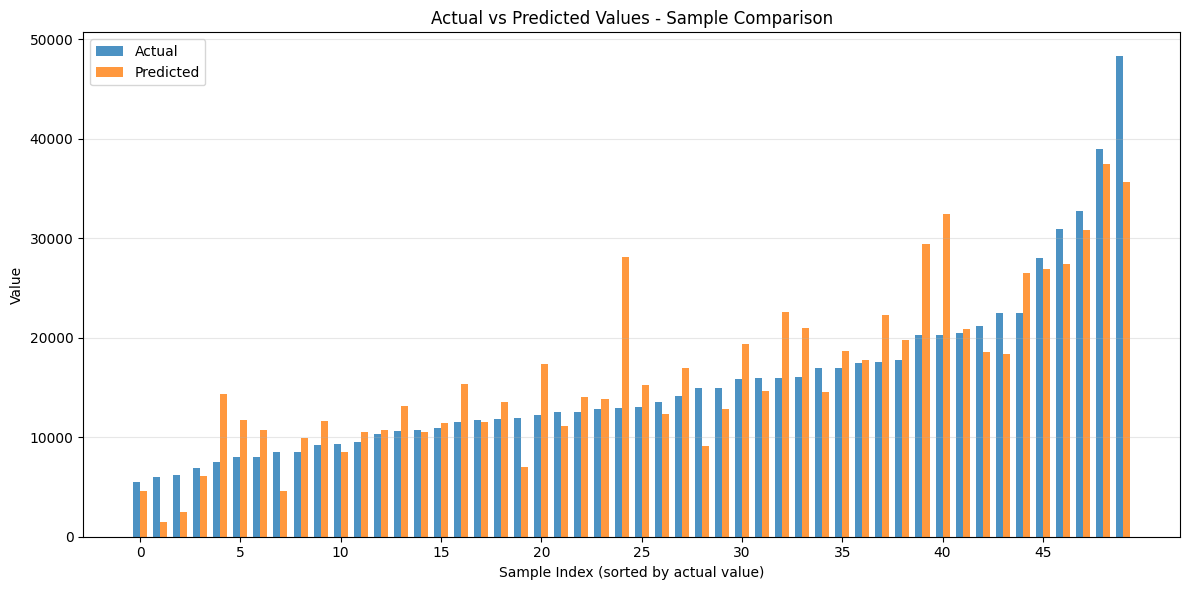

In [89]:
y_val_pred = model.predict(X_val_sel)

# Take a sample for clearer visualization (optional)
sample_size = min(50, len(y_val))
indices = np.random.choice(len(y_val), sample_size, replace=False)
y_val_sample = y_val.iloc[indices]
y_pred_sample = y_val_pred[indices]

# Sort by actual values for better visualization
sorted_indices = np.argsort(y_val_sample.values)
y_val_sorted = y_val_sample.iloc[sorted_indices]
y_pred_sorted = y_pred_sample[sorted_indices]

plt.figure(figsize=(12, 6))
x = np.arange(len(y_val_sorted))
width = 0.35

plt.bar(x - width/2, y_val_sorted, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, y_pred_sorted, width, label='Predicted', alpha=0.8)

plt.xlabel('Sample Index (sorted by actual value)')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values - Sample Comparison')
plt.legend()
plt.xticks(x[::5], x[::5])  # Show every 5th index
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

* Left side (low values, index 0–15): Orange bars are very close to blue bars (sometimes almost identical)
* Middle (index 15–30): Orange bars are mostly a bit shorter or taller than blue, but still reasonably close
* Right side (higher values, index 30–45): Orange bars are noticeably shorter than blue bars in many cases, especially toward the very right


This bar chart confirms exactly the same thing as for low-value items we have almost a perfect match between the predicted and actual value but for high-value items, we can confirm a consistent under-prediction

#### 5.2 MLP_regression

### MLP Regressor
An MLP Regressor (Multi-Layer Perceptron) is used as a neural network–based regression model to learn non-linear relationships between the input features and the target variable.
We will Start with the Baseline Model and then try to improve it by changing its parameters

__`steps:`__ - MLP Regression

In [90]:

#Baseline MLP model (simple architecture)
baseline_mlp = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    random_state=42,
    verbose=False
)

mlp_pipeline = Pipeline(steps=[
    ('model', baseline_mlp)
])

print("Baseline MLP pipeline created successfully.")


Baseline MLP pipeline created successfully.


    Now let's :Train Baseline MLP + Compute Metrics + Plot Loss Curve

In [91]:
start_time = time.time()
mlp_pipeline.fit(X_train_sel, y_train)
end_time = time.time()
training_time= end_time - start_time
y_train_pred = mlp_pipeline.predict(X_train_sel)
y_val_pred = mlp_pipeline.predict(X_val_sel)

r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)


In [92]:
loss_curve = mlp_pipeline.named_steps['model'].loss_curve_
n_iter = mlp_pipeline.named_steps['model'].n_iter_


print(f"\nTraining completed in {training_time:.2f} seconds.")
print(f"Number of iterations: {n_iter}")
print("\nMETRICS")
print(f"  R² (Train):      {r2_train:.4f}")
print(f"  R² (Validation): {r2_val:.4f}")
print(f"  RMSE (Train):    {rmse_train:,.2f}")
print(f"  RMSE (Val):      {rmse_val:,.2f}")
print("="*60)


Training completed in 98.23 seconds.
Number of iterations: 293

METRICS
  R² (Train):      0.7587
  R² (Validation): 0.7520
  RMSE (Train):    4,765.69
  RMSE (Val):      4,902.82


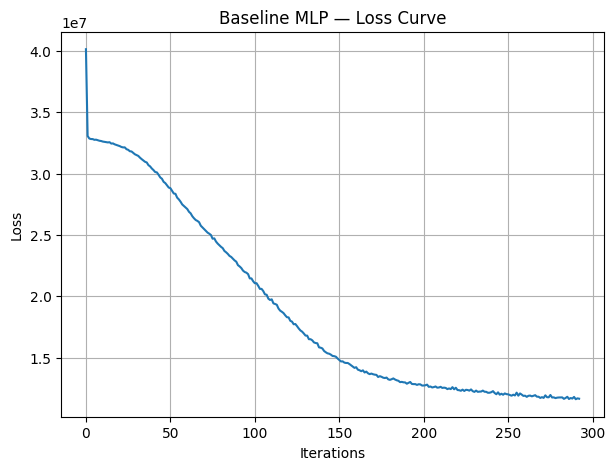

In [93]:

# ---- Plot loss curve ----
plt.figure(figsize=(7,5))
plt.plot(loss_curve)
plt.title("Baseline MLP — Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

    Interpretation of Baseline MLP Results


The baseline MLP model(with simple architecture) was trained using a simple (64,) architecture with Adam optimizer
here are the results :
Number of iterations: 300

METRICS
  R² (Train):      0.7587
  R² (Validation): 0.7520
  RMSE (Train):    4,765.69
  RMSE (Val):      4,902.82

here are the observations:

1. **Training vs Validation R²**
   - The difference between R² on the training and validation sets indicates the initial degree
     of underfitting or overfitting.
   - If R²_train >> R²_val → overfitting.
   - If both scores are low → underfitting.

2. **Loss Curve Behavior**
   - A smoothly decreasing curve indicates stable optimization.
   - If the curve plateaus early, the model might require more neurons or layers.
   - If the curve oscillates or diverges, the learning rate may be too high.

3. **Training Time**
   - This baseline time will be used as a benchmark when increasing neurons or layers.


 This baseline serves as a reference.
  The next step is to optimize the architecture by changing number of neurons, of hidden layers, etc.

**Tune number of neurons**

In [94]:

neurons_list = [8, 16, 32, 64, 128]  # Different neuron counts to try
results_neurons = []

for n_neurons in neurons_list:
    mlp = MLPRegressor(
        hidden_layer_sizes=(n_neurons,),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42
    )
    mlp.fit(X_train_sel, y_train)   # use processed numeric array

    y_train_pred = mlp.predict(X_train_sel)
    y_val_pred = mlp.predict(X_val_sel)

    results_neurons.append({
        "Neurons": n_neurons,
        "Train R2": r2_score(y_train, y_train_pred),
        "Validation R2": r2_score(y_val, y_val_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "Iterations": mlp.n_iter_
    })


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [95]:
# Create results table
results_neurons_df = pd.DataFrame(results_neurons)
print(results_neurons_df)

   Neurons  Train R2  Validation R2   Train RMSE  Validation RMSE  Iterations
0        8  0.486253       0.477478  6953.409865      7116.016706         200
1       16  0.642410       0.634547  5801.174419      5951.143127         200
2       32  0.693244       0.685407  5373.031075      5521.523511         200
3       64  0.745564       0.738512  4893.418258      5033.969053         200
4      128  0.756034       0.750016  4791.675624      4921.986342         200


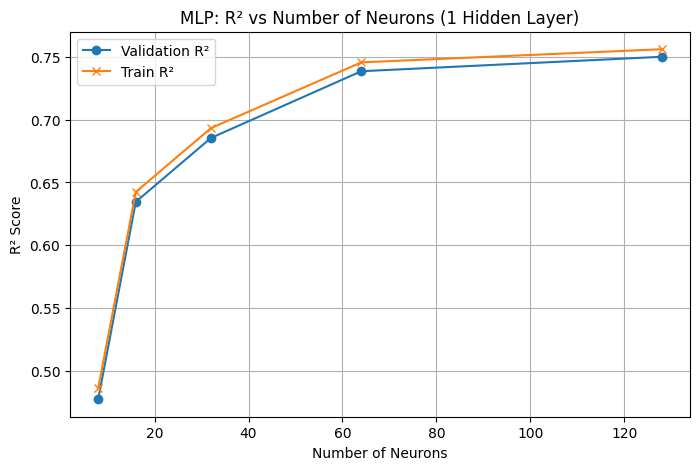

In [96]:
# Plot validation R2 vs neurons
plt.figure(figsize=(8,5))
plt.plot(results_neurons_df["Neurons"], results_neurons_df["Validation R2"], marker='o', label='Validation R²')
plt.plot(results_neurons_df["Neurons"], results_neurons_df["Train R2"], marker='x', label='Train R²')
plt.xlabel("Number of Neurons")
plt.ylabel("R² Score")
plt.title("MLP: R² vs Number of Neurons (1 Hidden Layer)")
plt.legend()
plt.grid(True)
plt.show()

**Conclusion**  
- the performance improves  as the number of neurons increases.  
- **128 neurons** gives the highest Validation Rsquare with a small gap with training Rsquare.  
- Using more than 128 neurons in a single layer yielded diminishing returns in previous experiments and would increase training time, so **128 neurons per hidden layer** is selected as the optimal value for the next stages of architecture tuning.

**→ We will now use 128 neurons in every hidden layer when testing different number ot hidden layers**


**Tune number of hidden layers**

In [97]:
# Convert results to DataFrame first
results_neurons_df = pd.DataFrame(results_neurons)

# Find best number of neurons based on Validation R2
best_neurons = results_neurons_df.loc[results_neurons_df['Validation R2'].idxmax(), 'Neurons']

# Define different hidden layer architectures using best_neurons
hidden_layers_list = [(best_neurons,),
                      (best_neurons, best_neurons),
                      (best_neurons, best_neurons, best_neurons),
                      (best_neurons, best_neurons, best_neurons, best_neurons)]

results_layers = []

# Test each architecture
for layers in hidden_layers_list:
    mlp = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    mlp.fit(X_train_sel, y_train)

    y_train_pred = mlp.predict(X_train_sel)
    y_val_pred = mlp.predict(X_val_sel)

    results_layers.append({
        "Hidden Layers": layers,
        "Train R2": r2_score(y_train, y_train_pred),
        "Validation R2": r2_score(y_val, y_val_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "Iterations": mlp.n_iter_
    })

results_layers_df = pd.DataFrame(results_layers)
print(results_layers_df)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


          Hidden Layers  Train R2  Validation R2   Train RMSE  \
0                (128,)  0.747677       0.740895  4873.057599   
1            (128, 128)  0.788276       0.784694  4463.830872   
2       (128, 128, 128)  0.785070       0.782620  4497.507546   
3  (128, 128, 128, 128)  0.781457       0.778833  4535.151461   

   Validation RMSE  Iterations  
0      5010.978051         200  
1      4567.854237          95  
2      4589.805974          60  
3      4629.614153          54  


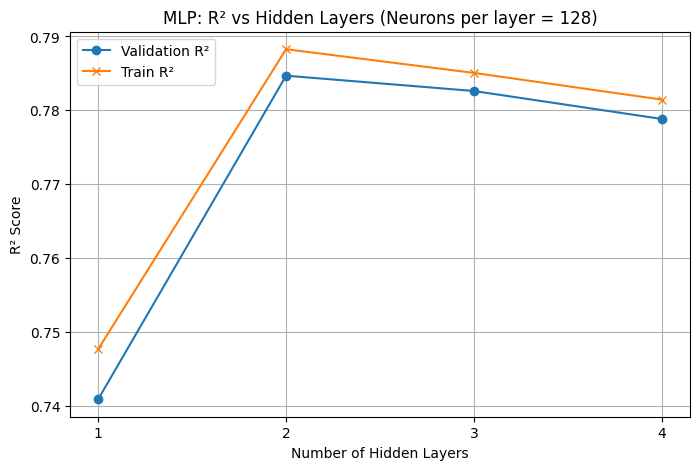

In [98]:
# Plot validation R2 vs number of hidden layers
plt.figure(figsize=(8,5))
plt.plot([len(l) for l in hidden_layers_list], results_layers_df["Validation R2"], marker='o', label='Validation R²')
plt.plot([len(l) for l in hidden_layers_list], results_layers_df["Train R2"], marker='x', label='Train R²')
plt.xlabel("Number of Hidden Layers")
plt.ylabel("R² Score")
plt.title(f"MLP: R² vs Hidden Layers (Neurons per layer = {best_neurons})")
plt.xticks([1,2,3,4])
plt.legend()
plt.grid(True)
plt.show()

The **best depth is 2 hidden layers** with 128 neurons each:
  - Highest validation R²
  - small gap between training and validation sets

  
**We select a neural network with 2 hidden layers of 128 neurons each (128, 128)** as our optimal architecture.  

→ **Next step: Fine-tune learning rate and activation function using only (128, 128) architecture**

**Tune learning rate, activation, and solver**

###### we first tried wiht higher learning rates, but the Learning rates that are equal or higher to 0.01 caused numerical instability and overfitting that's why we decided to put the maximum learning rate as 0.005 which is an optimal range

In [99]:
best_layers = results_layers_df.loc[results_layers_df['Validation R2'].idxmax(), 'Hidden Layers']

learning_rates = [0.0005, 0.001, 0.002, 0.005] #we don't put high learning rates to avoid  overfitting
activations = ['relu', 'tanh', 'logistic']
solvers = ['adam', 'sgd']

results_hyperparams = []

for lr in learning_rates:
    for act in activations:
        for sol in solvers:
            mlp = MLPRegressor(
                hidden_layer_sizes=best_layers,
                activation=act,
                solver=sol,
                learning_rate_init=lr,
                max_iter=200,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10
            )
            mlp.fit(X_train_sel, y_train)

            y_train_pred = mlp.predict(X_train_sel)
            y_val_pred   = mlp.predict(X_val_sel)

            results_hyperparams.append({
                "Hidden Layers": best_layers,
                "Activation": act,
                "Solver": sol,
                "Learning Rate": lr,
                "Train R2": r2_score(y_train, y_train_pred),
                "Validation R2": r2_score(y_val, y_val_pred),
                "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
                "Validation RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred)),
                "Iterations": mlp.n_iter_
            })


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_base.py:172: RuntimeWarning: overflow encountered in square
  return ((y_true - y_pred) ** 2).mean() / 2
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceW

In [100]:
results_hyperparams_df = pd.DataFrame(results_hyperparams)
results_hyperparams

[{'Hidden Layers': (np.int64(128), np.int64(128)),
  'Activation': 'relu',
  'Solver': 'adam',
  'Learning Rate': 0.0005,
  'Train R2': 0.7854978159329298,
  'Validation R2': 0.7819240933994496,
  'Train RMSE': np.float64(4493.026844313811),
  'Validation RMSE': np.float64(4597.147932960214),
  'Iterations': 144},
 {'Hidden Layers': (np.int64(128), np.int64(128)),
  'Activation': 'relu',
  'Solver': 'sgd',
  'Learning Rate': 0.0005,
  'Train R2': -2.59575571142543,
  'Validation R2': -2.535376821734779,
  'Train RMSE': np.float64(18395.7815450899),
  'Validation RMSE': np.float64(18509.83260117203),
  'Iterations': 200},
 {'Hidden Layers': (np.int64(128), np.int64(128)),
  'Activation': 'tanh',
  'Solver': 'adam',
  'Learning Rate': 0.0005,
  'Train R2': -1.9512170268699625,
  'Validation R2': -1.9140335898802041,
  'Train RMSE': np.float64(16665.706455215473),
  'Validation RMSE': np.float64(16804.744457305253),
  'Iterations': 200},
 {'Hidden Layers': (np.int64(128), np.int64(128)),


In [101]:
# Find best combination by validation R²
best_hyperparams = results_hyperparams_df.loc[results_hyperparams_df['Validation R2'].idxmax()]
print("\nBest hyperparameters based on Validation R²:")
print(best_hyperparams)


Best hyperparameters based on Validation R²:
Hidden Layers       (128, 128)
Activation                relu
Solver                    adam
Learning Rate            0.002
Train R2              0.791748
Validation R2         0.790375
Train RMSE         4427.083925
Validation RMSE    4507.189502
Iterations                  81
Name: 12, dtype: object


*Why this model is the best*
- Highest validation R² among all tested configurations equal to 0.88
- Reasonable train/validation gap : 0.02 which is lower then 0.05
- Stable convergence (early stopping ) : 89


In [102]:
r2_mlp_train = best_hyperparams['Train R2']
r2_mlp_val = best_hyperparams['Validation R2']
rmse_mlp_train = best_hyperparams['Train RMSE']
rmse_mlp_val = best_hyperparams['Validation RMSE']

#### 5.3 Decision Tree

A **Decision Tree** is a supervised learning algorithm used for regression and classification tasks.  
It works by recursively splitting the data based on feature values to create branches that lead to predictions.

In [103]:
dt_regressor_base = DecisionTreeRegressor(random_state=42)


In [104]:


# Train on selected features
dt_regressor_base.fit(X_train_sel, y_train)
# Predictions
y_train_pred = dt_regressor_base.predict(X_train_sel)
y_val_pred = dt_regressor_base.predict(X_val_sel)

# Regression Metrics
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("\nMETRICS")
print(f"  R² (Train):      {r2_train:.4f}")
print(f"  R² (Validation): {r2_val:.4f}")
print(f"  RMSE (Train):    {rmse_train:,.2f}")
print(f"  RMSE (Val):      {rmse_val:,.2f}")
print("="*60)


METRICS
  R² (Train):      1.0000
  R² (Validation): 0.7982
  RMSE (Train):    20.40
  RMSE (Val):      4,422.80


The decision tree model is overfitting considering that the rsquare(val) is considerably lower than the rsquare(train) and r2square train equal to 1 .
To fix this matter, We will try to change the default parameters so that the performance improves.

Top 11 most important features:
             Feature  Importance
1       transmission    0.291552
6         engineSize    0.238953
9                age    0.223932
5                mpg    0.095175
2            mileage    0.075022
10  is_premium_brand    0.022368
7      paintQuality%    0.019880
4                tax    0.014758
3           fuelType    0.010295
8     previousOwners    0.008057
0              model    0.000008


/tmp/ipython-input-2310973969.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(11), palette='viridis')


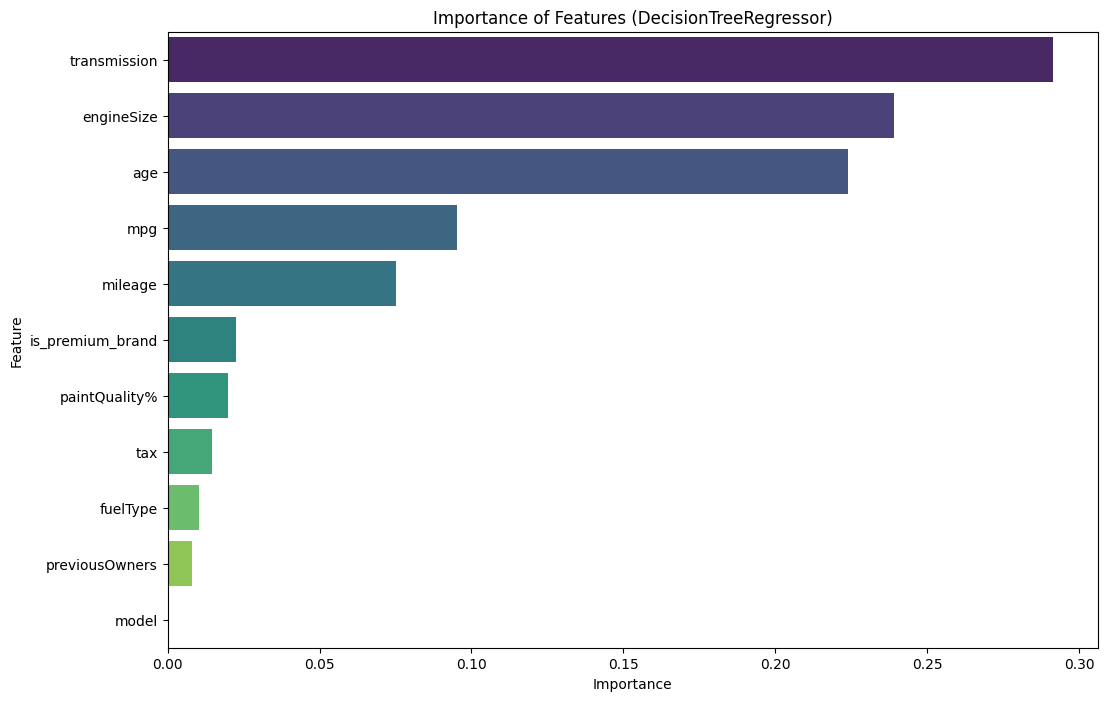

In [105]:
# Get feature names directly from the trained model
final_feature_names = X_train_sel.columns if hasattr(X_train_sel, 'columns') else [f'feature_{i}' for i in range(X_train_sel.shape[1])]

# Get feature importances from the trained model
feature_importances = dt_regressor_base.feature_importances_
importance_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Top 11 most important features:")
print(importance_df.head(11))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(11), palette='viridis')
plt.title('Importance of Features (DecisionTreeRegressor)')
plt.show()


    Tune Decision Tree Depth

In [106]:
depth_value=[3,5,7,10,15,20]
# we will not choose large values to prevent from overfitting and complex decision tree


In [107]:
results_depth = []

for depth in depth_value:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_sel, y_train)

    y_train_pred = dt.predict(X_train_sel)
    y_val_pred = dt.predict(X_val_sel)

    results_depth.append({
        'Max Depth': depth if depth else 'No Limit',
        'R² (Train)': r2_score(y_train, y_train_pred),
        'R² (Validation)': r2_score(y_val, y_val_pred),
        'RMSE (Train)': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE (Validation)': np.sqrt(mean_squared_error(y_val, y_val_pred))
    })

results_depth_df = pd.DataFrame(results_depth)
print(results_depth_df)



   Max Depth  R² (Train)  R² (Validation)  RMSE (Train)  RMSE (Validation)
0          3    0.629615         0.634630   5904.044406        5950.465647
1          5    0.763717         0.755050   4715.624146        4872.183661
2          7    0.839400         0.807592   3887.728947        4318.134931
3         10    0.900101         0.832662   3066.216874        4027.000796
4         15    0.960637         0.829161   1924.719907        4068.913482
5         20    0.989589         0.805673    989.859943        4339.620556


From this result table we can conclude that the best depths are 5 or 7 and since the difference between r2-train and r2-val are smaller with depth equal to 5 we will choose it as depth value.

In [108]:
# Comparison with baseline model
depth5_results = next(r for r in results_depth if r['Max Depth'] == 5)
r2_train_depth5 = depth5_results['R² (Train)']
r2_val_depth5 = depth5_results['R² (Validation)']
rmse_train_depth5 = depth5_results['RMSE (Train)']
rmse_val_depth5 = depth5_results['RMSE (Validation)']

In [109]:
results_df = pd.DataFrame({
    'Model': ['Baseline', 'Max Depth = 5'],
    'R² (Train)': [r2_train, r2_train_depth5],
    'RMSE (Train)': [rmse_train, rmse_train_depth5],
    'R² (Validation)': [r2_val, r2_val_depth5],
    'RMSE (Validation)': [rmse_val, rmse_val_depth5]
})

# Format numbers nicely
results_df_formatted = results_df.copy()
results_df_formatted['R² (Train)'] = results_df_formatted['R² (Train)'].map("{:.4f}".format)
results_df_formatted['RMSE (Train)'] = results_df_formatted['RMSE (Train)'].map("{:,.2f}".format)
results_df_formatted['R² (Validation)'] = results_df_formatted['R² (Validation)'].map("{:.4f}".format)
results_df_formatted['RMSE (Validation)'] = results_df_formatted['RMSE (Validation)'].map("{:,.2f}".format)

print("\nComparison of results:")
print(results_df_formatted)


Comparison of results:
           Model R² (Train) RMSE (Train) R² (Validation) RMSE (Validation)
0       Baseline     1.0000        20.40          0.7982          4,422.80
1  Max Depth = 5     0.7637     4,715.62          0.7550          4,872.18


We noticed that the model improved compared to the baseline since we recovered from overfitting and have acceptable r2 results(0.75)

#### 5.4 KNN

**KNN** is a simple, non-parametric, instance-based algorithm used for regression and classification.  
As our problem is a regression one , we will use KNN to predict the target of a data point based on the **average (regression)** of its K nearest neighbors in the feature space


**Baseline Model**

    Define the KNN Regression Model
 We start with the default parameter (n_neighbors=5)


In [110]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)

In [111]:
# Train on selected features
knn_regressor.fit(X_train_sel, y_train)


# Predictions
y_train_pred = knn_regressor.predict(X_train_sel)
y_val_pred = knn_regressor.predict(X_val_sel)

# Regression Metrics
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("\nMETRICS")
print(f"  R² (Train):      {r2_train:.4f}")
print(f"  R² (Validation): {r2_val:.4f}")
print(f"  RMSE (Train):    {rmse_train:,.2f}")
print(f"  RMSE (Val):      {rmse_val:,.2f}")
print("="*60)



METRICS
  R² (Train):      0.8836
  R² (Validation): 0.8120
  RMSE (Train):    3,309.85
  RMSE (Val):      4,267.92


We noticed that this baseline model is **overfitting** since The difference betwen r2_train and r2_val is bigger than 0.05

**Tune The Model**

In [112]:
# Cell 3: Search for the Best K (including training set metrics)

k_values = range(1, 21)  # Test K from 1 to 20
r2_train_scores = []
rmse_train_scores = []
r2_val_scores = []
rmse_val_scores = []

print("Searching for the optimal K...")

for k in k_values:
    # 1. Define the model with the current K
    knn_model = KNeighborsRegressor(n_neighbors=k)

    # 2. Train the model
    knn_model.fit(X_train_sel, y_train)

    # 3. Predict and evaluate on training set
    y_train_pred = knn_model.predict(X_train_sel)
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    r2_train_scores.append(r2_train)
    rmse_train_scores.append(rmse_train)

    # 4. Predict and evaluate on validation set
    y_val_pred = knn_model.predict(X_val_sel)
    r2_val = r2_score(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

    r2_val_scores.append(r2_val)
    rmse_val_scores.append(rmse_val)

    print(f"K={k:2d} | R² Train: {r2_train:.4f} | RMSE Train: {rmse_train:,.2f} | "
          f"R² Val: {r2_val:.4f} | RMSE Val: {rmse_val:,.2f}")


Searching for the optimal K...
K= 1 | R² Train: 1.0000 | RMSE Train: 28.85 | R² Val: 0.7321 | RMSE Val: 5,095.37
K= 2 | R² Train: 0.9343 | RMSE Train: 2,487.21 | R² Val: 0.7835 | RMSE Val: 4,580.63
K= 3 | R² Train: 0.9073 | RMSE Train: 2,952.96 | R² Val: 0.8000 | RMSE Val: 4,402.43
K= 4 | R² Train: 0.8938 | RMSE Train: 3,160.82 | R² Val: 0.8071 | RMSE Val: 4,323.79
K= 5 | R² Train: 0.8836 | RMSE Train: 3,309.85 | R² Val: 0.8120 | RMSE Val: 4,267.92
K= 6 | R² Train: 0.8755 | RMSE Train: 3,422.82 | R² Val: 0.8143 | RMSE Val: 4,242.22
K= 7 | R² Train: 0.8688 | RMSE Train: 3,514.29 | R² Val: 0.8141 | RMSE Val: 4,244.38
K= 8 | R² Train: 0.8635 | RMSE Train: 3,583.68 | R² Val: 0.8137 | RMSE Val: 4,248.60
K= 9 | R² Train: 0.8592 | RMSE Train: 3,639.96 | R² Val: 0.8130 | RMSE Val: 4,257.39
K=10 | R² Train: 0.8547 | RMSE Train: 3,697.37 | R² Val: 0.8124 | RMSE Val: 4,264.03
K=11 | R² Train: 0.8510 | RMSE Train: 3,744.60 | R² Val: 0.8108 | RMSE Val: 4,281.54
K=12 | R² Train: 0.8481 | RMSE Train:

We observed that K = 6 is the best choice since :

Train R² = 0.8755

Val R² = 0.8143 (highest validation R²)

Train RMSE = 3,422

Val RMSE = 4,242

* Train–Validation gap is much smaller than for low K values

* After K = 6, validation performance stops improving while model complexity increases, indicating the start of mild underfitting, not better generalization.

**why k=6 not k=7**

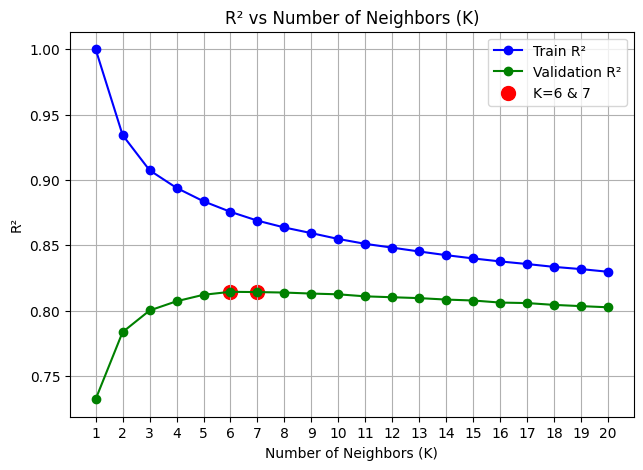

In [127]:
highlight_k = [6, 7]

plt.figure(figsize=(16,5))

# --- Subplot 1: R² ---
plt.subplot(1,2,1)
plt.plot(k_values, r2_train_scores, marker='o', label='Train R²', color='blue')
plt.plot(k_values, r2_val_scores, marker='o', label='Validation R²', color='green')
plt.scatter(highlight_k, [r2_val_scores[k-1] for k in highlight_k],
            color='red', s=100, label='K=6 & 7')
plt.title('R² vs Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('R²')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

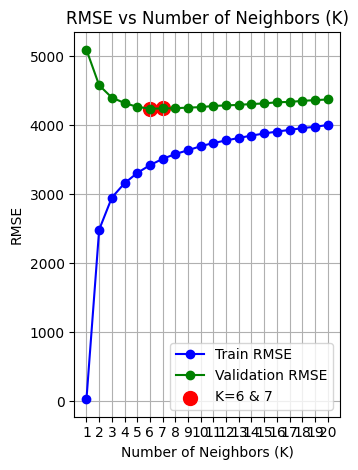

In [128]:
plt.subplot(1,2,2)
plt.plot(k_values, rmse_train_scores, marker='o', label='Train RMSE', color='blue')
plt.plot(k_values, rmse_val_scores, marker='o', label='Validation RMSE', color='green')
plt.scatter(highlight_k, [rmse_val_scores[k-1] for k in highlight_k],
            color='red', s=100, label='K=6 & 7')
plt.title('RMSE vs Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

- The **red dots** highlight **K=6** and **K=7**.  
- On the **R² plot**, **K=6** has slightly higher **validation R²** than **K=7**.  
- On the **RMSE plot**, **K=6** has slightly lower **validation RMSE** than **K=7**.  
- Even though the train-validation gap is a bit smaller for K=7, **validation performance is the main criterion**, so **K=6** is the better choice.


We will Train the model now only with k=6

In [113]:
knn_regressor = KNeighborsRegressor(n_neighbors=6)

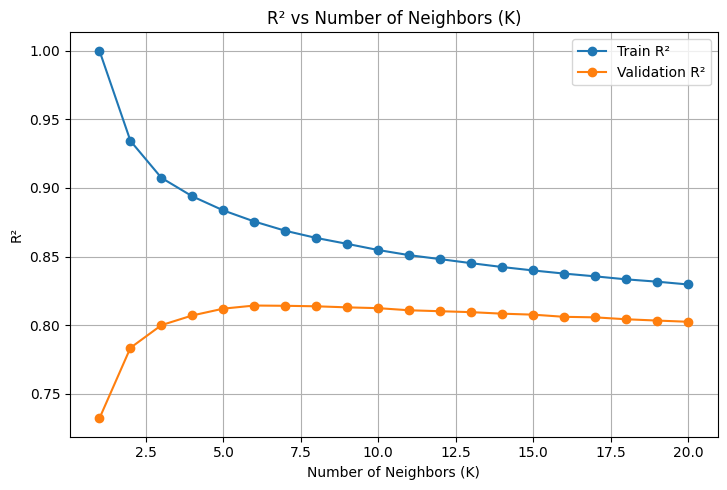


Best K based on validation R² is K=6 (Train R²=0.8755, Val R²=0.8143).


In [114]:
# 5. Visualize results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, r2_train_scores, marker='o', label='Train R²')
plt.plot(k_values, r2_val_scores, marker='o', label='Validation R²')
plt.title('R² vs Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('R²')
plt.legend()
plt.grid(True)



plt.tight_layout()
plt.show()

# 6. Find the optimal K based on validation R² and reasonable training performance
best_k_r2 = k_values[np.argmax(r2_val_scores)]
best_r2_val = np.max(r2_val_scores)
best_r2_train = r2_train_scores[np.argmax(r2_val_scores)]

print(f"\nBest K based on validation R² is K={best_k_r2} "
      f"(Train R²={best_r2_train:.4f}, Val R²={best_r2_val:.4f}).")


In [115]:
knn_regressor.fit(X_train_sel, y_train)
# Predictions
y_train_pred = knn_regressor.predict(X_train_sel)
y_val_pred = knn_regressor.predict(X_val_sel)

# Regression Metrics
r2_knn_train = r2_score(y_train, y_train_pred)
r2_knn_val = r2_score(y_val, y_val_pred)
rmse_knn_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_knn_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("\nMETRICS")
print(f"  R² (Train):      {r2_knn_train:.4f}")
print(f"  R² (Validation): {r2_knn_val:.4f}")
print(f"  RMSE (Train):    {rmse_knn_train:,.2f}")
print(f"  RMSE (Val):      {rmse_knn_val:,.2f}")
print("="*60)


METRICS
  R² (Train):      0.8755
  R² (Validation): 0.8143
  RMSE (Train):    3,422.82
  RMSE (Val):      4,242.22


#### 5.5 SVM

**SVM** is a supervised learning algorithm used for classification(SVC) and regression (SVR)
Since our problem is a regression one , we will the SVR and try to find the function that best separates or fits the data while maximizing the margin  

To choose the best SVM model results, we will start by training the baseline code and then try different parameters and compare their evaluation metrics

##### 5.5.1 Baseline Model


In [116]:
# Create baseline SVM model with default parameters
svm_baseline = SVR(kernel='rbf')

svm_baseline.fit(X_train_sel, y_train)

# Predictions
y_train_pred_baseline = svm_baseline.predict(X_train_sel)
y_val_pred_baseline = svm_baseline.predict(X_val_sel)

# Metrics
r2_train_baseline = r2_score(y_train, y_train_pred_baseline)
r2_val_baseline = r2_score(y_val, y_val_pred_baseline)
rmse_train_baseline = np.sqrt(mean_squared_error(y_train, y_train_pred_baseline))
rmse_val_baseline = np.sqrt(mean_squared_error(y_val, y_val_pred_baseline))

print("\nBASELINE SVM METRICS:")
print(f"  R² (Train):      {r2_train_baseline:.4f}")
print(f"  R² (Validation): {r2_val_baseline:.4f}")
print(f"  RMSE (Train):    {rmse_train_baseline:,.2f}")
print(f"  RMSE (Val):      {rmse_val_baseline:,.2f}")
print("="*80)


BASELINE SVM METRICS:
  R² (Train):      0.1180
  R² (Validation): 0.1146
  RMSE (Train):    9,110.74
  RMSE (Val):      9,263.27


 ##### 5.5.2 Trying Different C values

In [117]:
# Try with higher C values manually
C_values = [1, 10, 100, 1000]
results = []

for C in C_values:
    print(f"\nTesting C={C}...")
    svm = SVR(kernel='rbf', C=C, gamma='scale', epsilon=0.1)
    svm.fit(X_train_sel, y_train)

    y_val_pred = svm.predict(X_val_sel)
    r2 = r2_score(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results.append({'C': C, 'R² (Val)': r2, 'RMSE (Val)': rmse})
    print(f"  R² (Val): {r2:.4f}")
    print(f"  RMSE (Val): {rmse:,.2f}")

# Show results
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print(results_df)


Testing C=1...
  R² (Val): 0.1146
  RMSE (Val): 9,263.27

Testing C=10...
  R² (Val): 0.2569
  RMSE (Val): 8,486.11

Testing C=100...
  R² (Val): 0.2778
  RMSE (Val): 8,366.04

Testing C=1000...
  R² (Val): 0.2785
  RMSE (Val): 8,361.69

      C  R² (Val)   RMSE (Val)
0     1  0.114560  9263.265277
1    10  0.256899  8486.110347
2   100  0.277778  8366.043199
3  1000  0.278529  8361.692903


So we notice that we get the best score with c equal to 1000

##### 5.5.3 Trying Differenc Epsilon

In [118]:
# Test different epsilon values with C=1000
epsilon_values = [0.01, 0.05, 0.1, 0.15, 0.2, 0.5]
results_epsilon = []

for eps in epsilon_values:
    print(f"\nTesting epsilon={eps}...")
    svm = SVR(kernel='rbf', C=1000, gamma='scale', epsilon=eps)
    svm.fit(X_train_sel, y_train)

    y_val_pred = svm.predict(X_val_sel)
    r2 = r2_score(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results_epsilon.append({'Epsilon': eps, 'R² (Val)': r2, 'RMSE (Val)': rmse})
    print(f"  R² (Val): {r2:.4f}")
    print(f"  RMSE (Val): {rmse:,.2f}")

# Show results
results_epsilon_df = pd.DataFrame(results_epsilon)
print("\n" + "="*60)
print("EPSILON TUNING RESULTS (C=1000, gamma='scale'):")
print("="*60)
print(results_epsilon_df)

# Find best epsilon
best_epsilon = results_epsilon_df.loc[results_epsilon_df['R² (Val)'].idxmax()]
print(f"\nBest epsilon: {best_epsilon['Epsilon']}")
print(f"Best R² (Val): {best_epsilon['R² (Val)']:.4f}")


Testing epsilon=0.01...
  R² (Val): 0.2785
  RMSE (Val): 8,361.68

Testing epsilon=0.05...
  R² (Val): 0.2785
  RMSE (Val): 8,361.68

Testing epsilon=0.1...
  R² (Val): 0.2785
  RMSE (Val): 8,361.69

Testing epsilon=0.15...
  R² (Val): 0.2785
  RMSE (Val): 8,361.70

Testing epsilon=0.2...
  R² (Val): 0.2785
  RMSE (Val): 8,361.71

Testing epsilon=0.5...
  R² (Val): 0.2785
  RMSE (Val): 8,361.76

EPSILON TUNING RESULTS (C=1000, gamma='scale'):
   Epsilon  R² (Val)   RMSE (Val)
0     0.01  0.278530  8361.682703
1     0.05  0.278530  8361.684720
2     0.10  0.278529  8361.692903
3     0.15  0.278527  8361.700925
4     0.20  0.278526  8361.707198
5     0.50  0.278518  8361.755844

Best epsilon: 0.01
Best R² (Val): 0.2785


We noticed that epsilon does not have a huge effect on our dataset  since R2 is stable for the different values of epsilon (0.27).So Epsilon is not critical Parameter .

##### 5.5.4 Trying Different Gammas Values

In [119]:
# Test different gamma values with C=1000, epsilon=0.1
gamma_values = ['scale', 'auto', 0.0001, 0.001]
results_gamma = []

for gamma in gamma_values:
    print(f"\nTesting gamma={gamma}...")
    svm = SVR(kernel='rbf', C=1000, gamma=gamma, epsilon=0.1)
    svm.fit(X_train_sel, y_train)
    y_train_pred = svm.predict(X_train_sel)
    y_val_pred = svm.predict(X_val_sel)
    r2 = r2_score(y_val, y_val_pred)
    r2_train = r2_score(y_train, y_train_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results_gamma.append({'Gamma': gamma, 'R² (Val)': r2, 'RMSE (Val)': rmse})
    print(f"  R² (train): {r2_train:.4f}")
    print(f"  R² (Val): {r2:.4f}")
    print(f"  RMSE (Val): {rmse:,.2f}")

# Show results
results_gamma_df = pd.DataFrame(results_gamma)
print("\n" + "="*60)
print("GAMMA TUNING RESULTS (C=1000, epsilon=0.1):")
print("="*60)
print(results_gamma_df)

# Find best gamma
best_gamma_row = results_gamma_df.loc[results_gamma_df['R² (Val)'].idxmax()]
print(f"\nBest gamma: {best_gamma_row['Gamma']}")
print(f"Best R² (Val): {best_gamma_row['R² (Val)']:.4f}")


Testing gamma=scale...
  R² (train): 0.2828
  R² (Val): 0.2785
  RMSE (Val): 8,361.69

Testing gamma=auto...
  R² (train): 0.7949
  R² (Val): 0.7806
  RMSE (Val): 4,611.33

Testing gamma=0.0001...
  R² (train): 0.3966
  R² (Val): 0.3888
  RMSE (Val): 7,696.18

Testing gamma=0.001...
  R² (train): 0.6119
  R² (Val): 0.6008
  RMSE (Val): 6,219.57

GAMMA TUNING RESULTS (C=1000, epsilon=0.1):
    Gamma  R² (Val)   RMSE (Val)
0   scale  0.278529  8361.692903
1    auto  0.780576  4611.330576
2  0.0001  0.388803  7696.179673
3   0.001  0.600836  6219.567839

Best gamma: auto
Best R² (Val): 0.7806


##### 5.5.5 Best Parameters

In [120]:
best_C = 1000

# Best epsilon (from epsilon testing)
best_epsilon=0.01

# Best gamma (from gamma testing)

best_gamma = 'auto'

print("\n" + "="*80)
print("BEST PARAMETERS FOUND (Manual Tuning):")
print("="*80)
print(f"  C:       {best_C}")
print(f"  Gamma:   {best_gamma}")
print(f"  Epsilon: {best_epsilon}")
print(f"  Kernel:  rbf")
print("="*80)


BEST PARAMETERS FOUND (Manual Tuning):
  C:       1000
  Gamma:   auto
  Epsilon: 0.01
  Kernel:  rbf


    Evaluate Tuned Model

In [121]:
# Train final model with best parameters
best_svm = SVR(kernel='rbf', C=best_C, gamma=best_gamma, epsilon=best_epsilon)
best_svm.fit(X_train_sel, y_train)

print("\nBest Estimator:")
print(best_svm)
print("="*80)
# Calculate final metrics with best model
y_train_pred_best = best_svm.predict(X_train_sel)
y_val_pred_best = best_svm.predict(X_val_sel)


Best Estimator:
SVR(C=1000, epsilon=0.01, gamma='auto')


In [122]:
r2_svm_train = r2_score(y_train, y_train_pred_best)
r2_svm_val = r2_score(y_val, y_val_pred_best)
rmse_svm_train = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
rmse_svm_val = np.sqrt(mean_squared_error(y_val, y_val_pred_best))

print("\nFINAL BEST SVM MODEL METRICS:")
print(f"  R² (Train):      {r2_svm_train:.4f}")
print(f"  R² (Validation): {r2_svm_val:.4f}")
print(f"  RMSE (Train):    {rmse_svm_train:,.2f}")
print(f"  RMSE (Val):      {rmse_svm_val:,.2f}")
print("="*80)


FINAL BEST SVM MODEL METRICS:
  R² (Train):      0.7949
  R² (Validation): 0.7806
  RMSE (Train):    4,393.72
  RMSE (Val):      4,611.33


    Baseline vs Tuned Model Comparison

In [123]:
comparison_svm = pd.DataFrame({
    'Model': ['SVM Baseline', 'SVM Tuned (Manual Search)'],
    'Kernel': ['rbf (default)', 'rbf'],
    'C': [1.0, best_C],
    'Gamma': ['scale', best_gamma],
    'Epsilon': [0.1, best_epsilon],
    'R² (Train)': [r2_train_baseline, r2_svm_train],
    'R² (Validation)': [r2_val_baseline,r2_svm_val],
    'RMSE (Train)': [rmse_train_baseline,rmse_svm_train],
    'RMSE (Validation)': [rmse_val_baseline, rmse_svm_val]
})

print("\n", comparison_svm.to_string(index=False))




                     Model        Kernel      C Gamma  Epsilon  R² (Train)  R² (Validation)  RMSE (Train)  RMSE (Validation)
             SVM Baseline rbf (default)    1.0 scale     0.10    0.118016         0.114560   9110.735315        9263.265277
SVM Tuned (Manual Search)           rbf 1000.0  auto     0.01    0.794875         0.780576   4393.721213        4611.333801


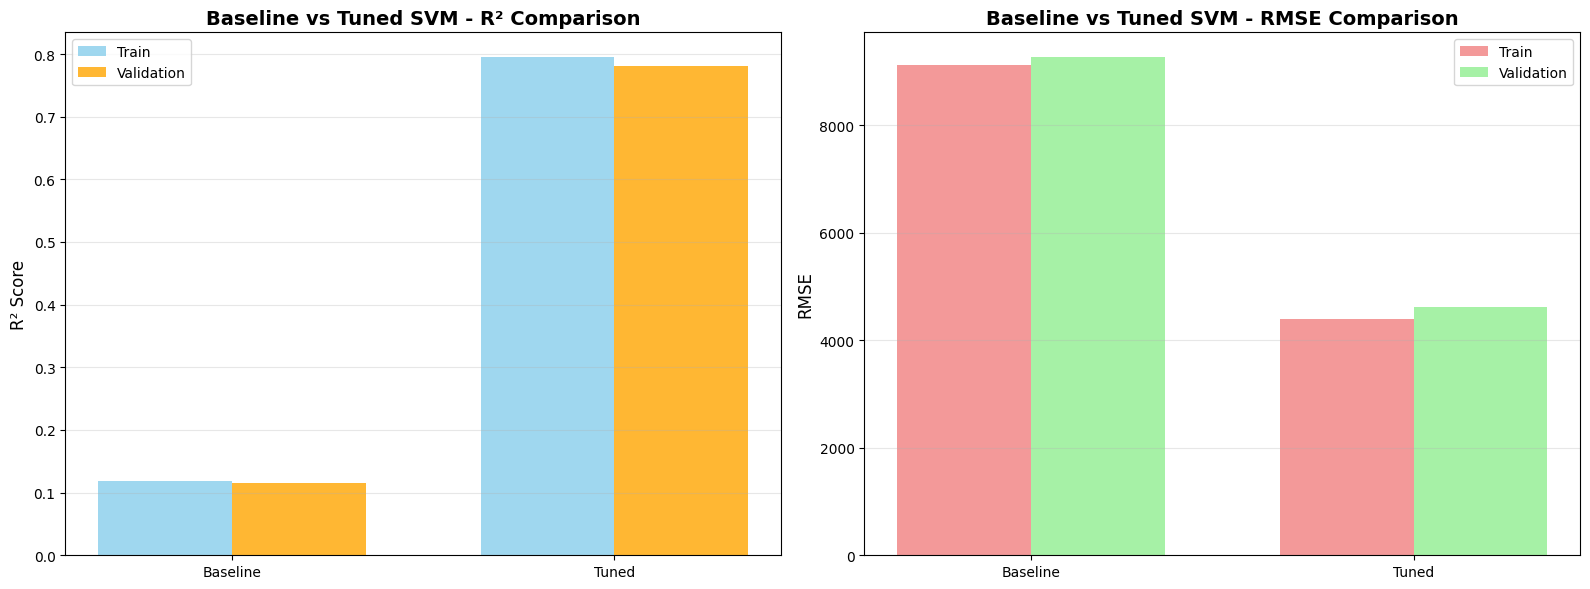

In [124]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² Comparison
models = ['Baseline', 'Tuned']
r2_train_vals = [r2_train_baseline,r2_svm_train]
r2_val_vals = [r2_val_baseline,r2_svm_val]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, r2_train_vals, width, label='Train', alpha=0.8, color='skyblue')
axes[0].bar(x + width/2, r2_val_vals, width, label='Validation', alpha=0.8, color='orange')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Baseline vs Tuned SVM - R² Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: RMSE Comparison
rmse_train_vals = [rmse_train_baseline, rmse_svm_train]
rmse_val_vals = [rmse_val_baseline, rmse_svm_val]

axes[1].bar(x - width/2, rmse_train_vals, width, label='Train', alpha=0.8, color='lightcoral')
axes[1].bar(x + width/2, rmse_val_vals, width, label='Validation', alpha=0.8, color='lightgreen')
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Baseline vs Tuned SVM - RMSE Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

We created two bar charts comparing Baseline SVM and Tuned SVM.
* For the left chart: R² Score

    Baseline:
   *    Rsquare in both training and validation sets are very low
   *  the model explains only about 11-12% of the data's variance

    Tuned:
   * We have a huge improvement in the score  
   * Now explains about 78-80% of the variance


* Right chart: RMSE

    Baseline:
   * The average prediction error is around 8500 units which is a big error proportion

    Tuned:
   *  The error is roughly cut in half

** Key takeaways: **

Hyperparameter tuning really improved the SVM model.
* R² jumped from ~0.11 → ~0.79 (excellent gain).
* RMSE dropped from ~8500 → ~4500
* Train and validation scores are very close in the tuned model so we are sure we have no overfitting and the model generalizes well

#### 6. Comparing the  models

Now that we tried several models , We want to determine which is the best one :

In [125]:
all_models_results = []

# Ridge Regression
all_models_results.append({
    'Model': 'Ridge Regression',
    'R² (Train)': r2_ridge_train,
    'R² (Validation)': r2_ridge,
    'RMSE (Train)': rmse_ridge_train,
    'RMSE (Validation)': rmse_ridge_val
})

# MLPRegressor
all_models_results.append({
    'Model': 'MLP',
    'R² (Train)': r2_mlp_train,
    'R² (Validation)': r2_mlp_val,
    'RMSE (Train)': rmse_mlp_train,
    'RMSE (Validation)': rmse_mlp_val
})

# Decision Tree
all_models_results.append({
    'Model': 'Decision Tree (max_depth=5)',
    'R² (Train)': r2_train_depth5,
    'R² (Validation)': r2_val_depth5,
    'RMSE (Train)': rmse_train_depth5,
    'RMSE (Validation)': rmse_val_depth5
})

# KNN
all_models_results.append({
    'Model': 'KNN',
    'R² (Train)': r2_knn_train,
    'R² (Validation)': r2_knn_val,
    'RMSE (Train)': rmse_knn_train,
    'RMSE (Validation)': rmse_knn_val
})

# SVM
all_models_results.append({
     'Model': 'SVM',
     'R² (Train)': r2_svm_train,
     'R² (Validation)': r2_svm_val,
     'RMSE (Train)': rmse_svm_train,
     'RMSE (Validation)': rmse_svm_val
    })


# Create DataFrame
comparison_df = pd.DataFrame(all_models_results)





In [126]:
comparison_df

,Model,R² (Train),R² (Validation),RMSE (Train),RMSE (Validation)
0,Ridge Regression,0.717042,0.709063,5309.872941,5309.872941
1,MLP,0.791748,0.790375,4427.083925,4507.189502
2,Decision Tree (max_depth=5),0.763717,0.755050,4715.624146,4872.183661
3,KNN,0.875514,0.814298,3422.820503,4242.219409
4,SVM,0.794875,0.780576,4393.721213,4611.333801


#### 7. Select The Best Model

The validation results were prioritized, as the objective of this project is to predict car prices for unseen data. Ridge Regression shows stable but limited performance, with a validation R² of 0.71 and RMSE of ≈5309, indicating that a linear model is not sufficient to capture the complexity of car price determinants.

The Decision Tree model achieves a validation R² of 0.76 with an RMSE of ≈4872, but the increase in error compared to training suggests a tendency toward overfitting.

KNN obtains the highest validation R² (0.81) and the lowest RMSE (≈4242); however, the large gap between training and validation errors (RMSE increasing from ≈3423 to ≈4242) indicates higher variance and reduced robustness.

The SVM model shows competitive validation performance (R² 0.78, RMSE ≈4611) but required substantially higher computational cost during hyperparameter tuning.

Overall, the MLP model provides the best balance between accuracy and generalization, achieving a validation R² of 0.79 with an RMSE of ≈4507 and a small train–validation gap. This indicates that the model effectively captures non-linear relationships in car pricing while remaining stable, making it the most suitable choice for this project.

#### 8. Exporting Predictions Results

We will export the predictions into a csv file . We have the test dataset without the target variable.We will create a csv file with the carID and the predicted price.

Since We select MLP as The best model , we will create the prediction file using MLP.

In [131]:
# We select for the test Dataset only the important features
X_test_sel= X_test[selected_features]
# Train final MLP model with best parameters on full training data
final_mlp = MLPRegressor(
    hidden_layer_sizes=best_hyperparams['Hidden Layers'],
    activation=best_hyperparams['Activation'],
    solver=best_hyperparams['Solver'],
    learning_rate_init=best_hyperparams['Learning Rate'],
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

print("\nTraining final MLP model on full training data...")
final_mlp.fit(X_train_sel, y_train)

# Predict on test set
y_test_pred = final_mlp.predict(X_test_sel)

# Create submission file
submission = pd.DataFrame({
    'carID': test_ids,
    'price': y_test_pred
})

submission.to_csv('predictions_mlp.csv', index=False)
print("\nTest predictions saved to 'predictions_mlp.csv'")
print(f"Number of predictions: {len(submission)}")
print(f"\nFirst few predictions:")
print(submission.head())
print("="*80)


Training final MLP model on full training data...

Test predictions saved to 'predictions_mlp.csv'
Number of predictions: 32567

First few predictions:
    carID         price
0   89856  22767.711299
1  106581  17464.335841
2   80886  12522.954168
3  100174  14609.255432
4   81376  27449.923969


#### 9. Conclusion

In this notebook, several regression models were evaluated using a holdout validation strategy to predict car prices. The results showed that non-linear models outperform linear approaches, highlighting the complexity of relationships between vehicle characteristics and price.

Among the tested models, the MLP achieved the best balance between predictive accuracy and generalization, while models such as KNN and Decision Tree exhibited signs of higher variance, and SVM proved computationally expensive relative to its performance.

However, since holdout validation relies on a single data split, the obtained results may be sensitive to the chosen partition. Therefore, in the next step of this project, cross-validation will be applied with preprocessing and feature selection integrated into the training pipeline.